In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import necessary libraries
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from torchsummary import summary
import seaborn as sns

In [ ]:
# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [ ]:
df = pd.read_csv("/content/drive/My Drive/KE/Dhaka_Dengue.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 460 entries, 0 to 459
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   month        460 non-null    object 
 1   year         460 non-null    int64  
 2   area         460 non-null    object 
 3   cases        460 non-null    int64  
 4   deaths       460 non-null    int64  
 5   temperature  460 non-null    float64
 6   humidity     460 non-null    int64  
 7   rainfall     460 non-null    int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 28.9+ KB


In [ ]:
obj = (df.dtypes == 'object')
print("Categorical variables:",len(list(obj[obj].index)))

Categorical variables: 2


In [ ]:
# statistical measures
df.describe()

,year,cases,deaths,temperature,humidity,rainfall
count,460.000000,460.000000,460.000000,460.000000,460.000000,460.000000
mean,2023.434783,110.226087,2.876087,27.290652,71.928261,184.500000
std,1.097674,87.941014,3.158120,4.674771,12.363999,126.941901
min,2022.000000,0.000000,0.000000,18.200000,50.000000,0.000000
25%,2022.000000,36.750000,0.000000,23.500000,61.000000,67.500000
50%,2023.000000,88.000000,2.000000,28.300000,75.000000,207.500000
75%,2024.000000,176.250000,5.000000,31.350000,83.000000,302.000000
max,2025.000000,300.000000,14.000000,33.900000,90.000000,400.000000


In [ ]:
# Create the TimePoint Entity
# Create a mapping from month names to numbers for a sortable date format (YYYY-MM)
month_to_num = {
    'January': '01', 'February': '02', 'March': '03', 'April': '04',
    'May': '05', 'June': '06', 'July': '07', 'August': '08',
    'September': '09', 'October': '10', 'November': '11', 'December': '12'
}
# Apply the mapping and create the month number column
df['month_num'] = df['month'].map(month_to_num)

# Combine year and month number to create the unique TimePoint identifier
df['TimePoint'] = df['year'].astype(str) + '-' + df['month_num']

In [ ]:
#Rename Area Column
# Rename 'area' to 'Area' for consistency with our defined entities
df = df.rename(columns={'area': 'Area'})

# Drop the now-redundant columns
df = df.drop(columns=['month', 'year', 'month_num'])

In [ ]:
# Display the transformed data
print("--- Transformed DataFrame Head (First 5 Rows) ---")
print(df[['TimePoint', 'Area', 'cases', 'deaths', 'temperature', 'humidity', 'rainfall']].head().to_markdown(index=False, numalign="left", stralign="left"))

# Print info to verify column types
print("\n--- Transformed DataFrame Info ---")
df.info()


--- Transformed DataFrame Head (First 5 Rows) ---
| TimePoint   | Area       | cases   | deaths   | temperature   | humidity   | rainfall   |
|:------------|:-----------|:--------|:---------|:--------------|:-----------|:-----------|
| 2022-01     | Dhanmondi  | 60      | 2        | 26.1          | 59         | 94         |
| 2022-01     | Keraniganj | 15      | 0        | 18.6          | 56         | 56         |
| 2022-01     | Khilgaon   | 0       | 0        | 26.1          | 56         | 20         |
| 2022-01     | Lalbagh    | 35      | 0        | 22.6          | 67         | 54         |
| 2022-01     | Mirpur     | 11      | 0        | 21.8          | 64         | 39         |

--- Transformed DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 460 entries, 0 to 459
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Area         460 non-null    object 
 1   cases        460 non-null    int64 

### --- STEP 2: TRIPLE GENERATION ---

In [ ]:

triples = []
# These are the attribute columns that will become literals (objects)
literal_cols = ['cases', 'deaths', 'temperature', 'humidity', 'rainfall']

# Iterate over all rows (Observations)
for index, row in df.iterrows():

    # 1. Define the unique Subject (Observation Entity)
    observation_id = f"Observation_{index}"

    # 2. Entity-to-Entity Triples
    # Observation HAS_AREA Area_Name
    triples.append((observation_id, "HAS_AREA", row['Area']))

    # Observation AT_TIME TimePoint_Value
    triples.append((observation_id, "AT_TIME", row['TimePoint']))

    # 3. Entity-to-Literal (Attribute) Triples
    for col in literal_cols:
        predicate = f"HAS_{col.upper()}"
        obj_literal = row[col]
        # Convert literals to string (or ensure type consistency) for graph loading
        triples.append((observation_id, predicate, str(obj_literal)))

In [ ]:
# The 'triples' variable now contains all 3360 triples.
print(f"Total number of triples generated: {len(triples)}")

Total number of triples generated: 3220


In [ ]:
# Show the triples
print(triples[:5])

[('Observation_0', 'HAS_AREA', 'Dhanmondi'), ('Observation_0', 'AT_TIME', '2022-01'), ('Observation_0', 'HAS_CASES', '60'), ('Observation_0', 'HAS_DEATHS', '2'), ('Observation_0', 'HAS_TEMPERATURE', '26.1')]


### --- STEP 3: Graph Storage and Implementation (NetworkX) ---

In [ ]:
import networkx as nx
# 1. Initialize a directed graph
G = nx.DiGraph()

In [ ]:
# 2. Iterate through triples and populate the graph
for subject, predicate, obj in triples:
    # Add an edge with the predicate as the relationship attribute ('label')
    G.add_edge(subject, obj, label=predicate)

In [ ]:
# 3. Graph Analysis/Verification
print("--- NetworkX Graph Summary ---")
print(f"Total Nodes (Entities + Literals): {G.number_of_nodes()}")
print(f"Total Edges (Relationships): {G.number_of_edges()}")

--- NetworkX Graph Summary ---
Total Nodes (Entities + Literals): 1001
Total Edges (Relationships): 3207


In [ ]:
# 4. Visualization (Only visualize the first observation to keep it readable)
first_observation_nodes = [t[0] for t in triples[:7]] + [t[2] for t in triples[:7]]
subgraph = G.subgraph(first_observation_nodes)

/tmp/ipython-input-4147796366.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()





Visualization saved as 'networkx_kg_subset_visualization.png'.


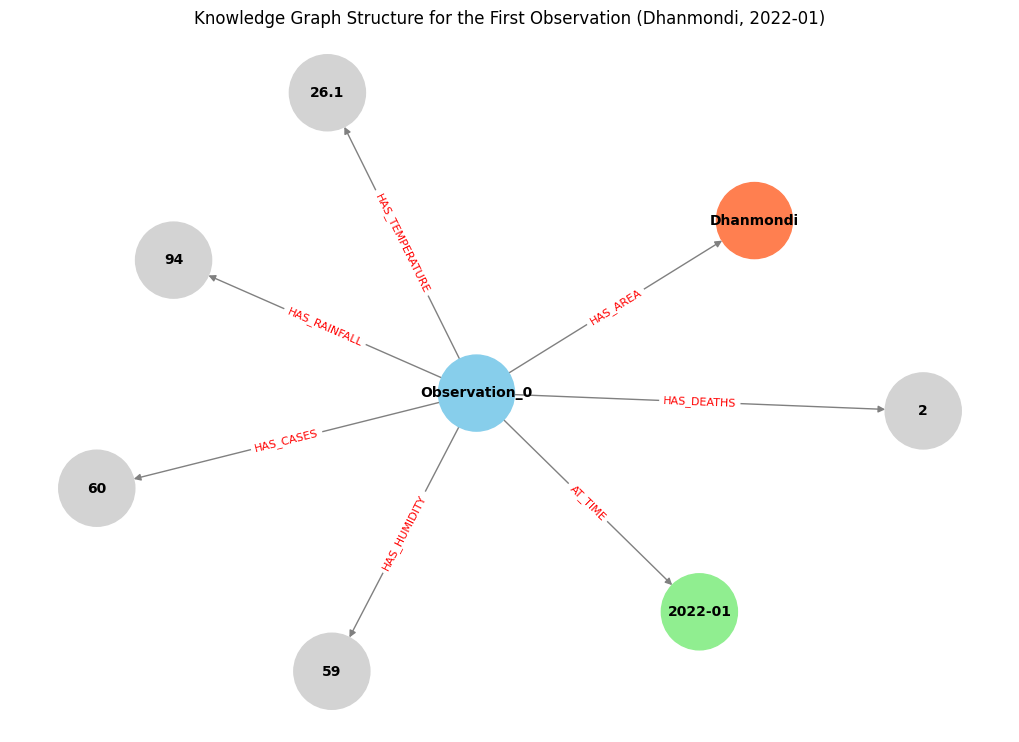

In [ ]:
# Define node colors based on type (simple heuristic)
node_colors = []
for node in subgraph.nodes():
    if node.startswith('Observation'):
        node_colors.append('skyblue') # Observation Entity
    elif '-' in node:
        node_colors.append('lightgreen') # TimePoint Entity (e.g., 2022-01)
    elif node in df['Area'].unique():
        node_colors.append('coral') # Area Entity
    else:
        node_colors.append('lightgray') # Literal/Attribute

plt.figure(figsize=(10, 7))
pos = nx.spring_layout(subgraph, k=0.8) # Position nodes using Fruchterman-Reingold force-directed algorithm
nx.draw(subgraph, pos,
        with_labels=True,
        node_size=3000,
        node_color=node_colors,
        font_size=10,
        font_weight='bold',
        edge_color='gray',
        arrows=True)
# Add edge labels (predicates)
edge_labels = nx.get_edge_attributes(subgraph, 'label')
nx.draw_networkx_edge_labels(subgraph, pos, edge_labels=edge_labels, font_size=8, font_color='red')

plt.title("Knowledge Graph Structure for the First Observation (Dhanmondi, 2022-01)", fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.savefig('networkx_kg_subset_visualization.png')
print("\n")
print("\nVisualization saved as 'networkx_kg_subset_visualization.png'.")



### --- STEP 4: QUERYING AND ANALYSIS ---

In [ ]:
# ----------------------------------------------------------------------
# ANALYSIS 1: Find the Area and Time with the Highest Number of Dengue Cases
# ----------------------------------------------------------------------

max_cases = -1
max_case_obs_id = None

# 1. Find the Observation node linked to the highest 'HAS_CASES' value
for subject, obj, data in G.edges(data=True):
    if data['label'] == 'HAS_CASES':
        # Safely convert the object (literal) to an integer
        try:
            cases = int(obj)
            if cases > max_cases:
                max_cases = cases
                max_case_obs_id = subject
        except ValueError:
            # Skip if the object is not an integer (shouldn't happen here)
            continue

# 2. Retrieve the Area and TimePoint for the max case Observation
max_area = None
max_timepoint = None

if max_case_obs_id:
    for neighbor, data in G[max_case_obs_id].items():
        if data['label'] == 'HAS_AREA':
            max_area = neighbor
        elif data['label'] == 'AT_TIME':
            max_timepoint = neighbor

print("------------------------------------------------------------------")
print("ANALYSIS 1: HIGHEST RECORDED DENGUE CASES")
print(f"Maximum Cases: {max_cases}")
print(f"Area: {max_area}")
print(f"TimePoint: {max_timepoint}")
print("------------------------------------------------------------------")

------------------------------------------------------------------
ANALYSIS 1: HIGHEST RECORDED DENGUE CASES
Maximum Cases: 300
Area: Shahbagh
TimePoint: 2022-09
------------------------------------------------------------------


In [ ]:
# ----------------------------------------------------------------------
# ANALYSIS 2: Find Observations where Cases > 200 AND Rainfall > 300 mm
# ----------------------------------------------------------------------

high_incidence_locations = []
CASES_THRESHOLD = 200
RAINFALL_THRESHOLD = 300

# Get all unique Observation nodes
observation_nodes = [n for n in G.nodes() if n.startswith('Observation_')]

for obs_id in observation_nodes:
    current_cases = 0
    current_rainfall = 0
    current_area = None
    current_timepoint = None

    # Check all outgoing edges (neighbors) from the Observation node
    for neighbor, data in G[obs_id].items():
        predicate = data['label']
        neighbor_value = neighbor

        if predicate == 'HAS_CASES':
            current_cases = int(neighbor_value)
        elif predicate == 'HAS_RAINFALL':
            current_rainfall = int(neighbor_value)
        elif predicate == 'HAS_AREA':
            current_area = neighbor_value
        elif predicate == 'AT_TIME':
            current_timepoint = neighbor_value

    # Check the combined conditions
    if current_cases > CASES_THRESHOLD and current_rainfall > RAINFALL_THRESHOLD:
        high_incidence_locations.append({
            'Area': current_area,
            'TimePoint': current_timepoint,
            'Cases': current_cases,
            'Rainfall': current_rainfall
        })

print("\n------------------------------------------------------------------")
print(f"ANALYSIS 2: HIGH CASES (> {CASES_THRESHOLD}) AND HIGH RAINFALL (> {RAINFALL_THRESHOLD} mm)")

if high_incidence_locations:
    # Convert results to a DataFrame for clean, sortable output
    results_df = pd.DataFrame(high_incidence_locations)
    results_df = results_df.sort_values(by=['TimePoint', 'Cases'], ascending=False)

    print(f"Total Observations Meeting Criteria: {len(results_df)}")
    print(results_df.to_markdown(index=False, numalign="left", stralign="left"))
else:
    print("No observations met both the high cases and high rainfall criteria.")

print("------------------------------------------------------------------")


------------------------------------------------------------------
ANALYSIS 2: HIGH CASES (> 200) AND HIGH RAINFALL (> 300 mm)
Total Observations Meeting Criteria: 37
| Area        | TimePoint   | Cases   | Rainfall   |
|:------------|:------------|:--------|:-----------|
| Shahbagh    | 2025-10     | 254     | 303        |
| Lalbagh     | 2025-09     | 286     | 329        |
| Khilgaon    | 2025-09     | 202     | 341        |
| Mohammadpur | 2025-08     | 211     | 352        |
| Rampura     | 2024-10     | 277     | 306        |
| Keraniganj  | 2024-09     | 274     | 301        |
| Lalbagh     | 2024-09     | 261     | 355        |
| Rampura     | 2024-09     | 234     | 338        |
| Shahbagh    | 2024-09     | 211     | 368        |
| Dhanmondi   | 2024-08     | 277     | 371        |
| Rampura     | 2024-08     | 254     | 380        |
| Khilgaon    | 2024-07     | 279     | 331        |
| Dhanmondi   | 2024-06     | 263     | 395        |
| Pallabi     | 2024-06     | 248    

In [ ]:
# ----------------------------------------------------------------------
# ANALYSIS 3: Identify the Central Entities using In-Degree Centrality
# ----------------------------------------------------------------------

# 1. Calculate the raw In-Degree for all nodes
in_degree_counts = dict(G.in_degree())

area_centrality = {}
timepoint_centrality = {}

# 2. Filter the degrees to identify the centrality of Area and TimePoint entities
for node, degree in in_degree_counts.items():
    # Node is an Area Entity if it's in the original 'Area' column and not a TimePoint or Literal
    if node in df['Area'].unique():
        area_centrality[node] = degree

    # Node is a TimePoint Entity if it's in the format YYYY-MM
    elif pd.to_datetime(node, format='%Y-%m', errors='coerce') is not pd.NaT:
        timepoint_centrality[node] = degree

# 3. Sort the results

# A. Centrality by Area (The most frequently observed/reported areas)
sorted_areas = sorted(area_centrality.items(), key=lambda item: item[1], reverse=True)

# B. Centrality by TimePoint (The months with the most observations, should be roughly equal)
sorted_timepoints = sorted(timepoint_centrality.items(), key=lambda item: item[1], reverse=True)


print("------------------------------------------------------------------")
print("ANALYSIS 3: IN-DEGREE CENTRALITY (RAW COUNT)")
print("------------------------------------------------------------------")

# Output for Area Entities
print("\nTop 5 Most Central Area Entities (Most Observed Areas):")
area_df = pd.DataFrame(sorted_areas, columns=['Area', 'Observation Count']).head(5)
print(area_df.to_markdown(index=False, numalign="left", stralign="left"))


# Output for TimePoint Entities
print("\nTop 5 Most Central TimePoint Entities (Months with Most Observations):")
timepoint_df = pd.DataFrame(sorted_timepoints, columns=['TimePoint', 'Observation Count']).head(5)
print(timepoint_df.to_markdown(index=False, numalign="left", stralign="left"))

print("------------------------------------------------------------------")

------------------------------------------------------------------
ANALYSIS 3: IN-DEGREE CENTRALITY (RAW COUNT)
------------------------------------------------------------------

Top 5 Most Central Area Entities (Most Observed Areas):
| Area       | Observation Count   |
|:-----------|:--------------------|
| Dhanmondi  | 46                  |
| Keraniganj | 46                  |
| Khilgaon   | 46                  |
| Lalbagh    | 46                  |
| Mirpur     | 46                  |

Top 5 Most Central TimePoint Entities (Months with Most Observations):
| TimePoint   | Observation Count   |
|:------------|:--------------------|
| 2022-01     | 10                  |
| 2022-02     | 10                  |
| 2022-03     | 10                  |
| 2022-04     | 10                  |
| 2022-05     | 10                  |
------------------------------------------------------------------


###KNOWLEDGE GRAPH ENHANCEMENT FOR PREDICTION

In [ ]:
# KNOWLEDGE GRAPH ENHANCEMENT FOR PREDICTION

# 1. Load Proximity Data
df_conn = pd.read_csv('/content/drive/My Drive/KE/connection.csv')
df_conn = df_conn.rename(columns={'area': 'Area'})

# 2. Add Proximity Relations (CLOSE_TO)
proximity_triples = []
for _, row in df_conn.iterrows():
    source_area = row['Area']
    connected_areas = [a.strip() for a in row['connected_areas'].split(',')]

    for target_area in connected_areas:
        proximity_triples.append((source_area, "CLOSE_TO", target_area))
        # Add reverse relation for undirected connection
        proximity_triples.append((target_area, "CLOSE_TO", source_area))

G.add_edges_from([(s, o, {'label': p}) for s, p, o in proximity_triples])

/tmp/ipython-input-3034357344.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()





Enhanced graph visualization (proximity relationships) saved as 'enhanced_kg_proximity_visualization.png'.


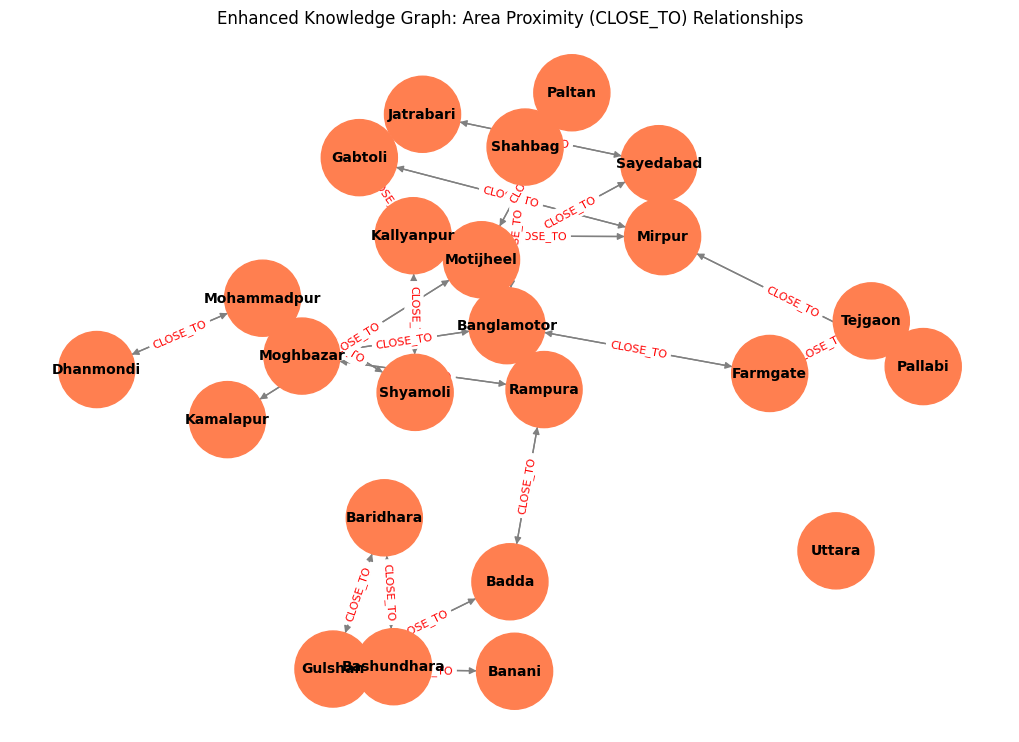

In [ ]:
# Select specific areas to visualize their proximity
selected_areas_to_visualize =  ["Mirpur", "Pallabi", "Mohammadpur", "Dhanmondi", "Uttara", "Banani", "Gulshan", "Baridhara", "Bashundhara", "Badda", "Tejgaon", "Farmgate", "Motijheel", "Paltan", "Shahbag", "Banglamotor", "Moghbazar", "Rampura", "Kallyanpur", "Gabtoli", "Shyamoli", "Jatrabari", "Sayedabad", "Kamalapur"]


# Create a subgraph focusing on proximity relationships between selected areas
proximity_subgraph = nx.DiGraph()

# Add nodes and 'CLOSE_TO' edges if both ends are in our selected visualization set
for u, v, data in G.edges(data=True):
    if data.get('label') == 'CLOSE_TO':
        if u in selected_areas_to_visualize and v in selected_areas_to_visualize:
            proximity_subgraph.add_edge(u, v, label='CLOSE_TO')

# Ensure all selected areas are in the subgraph even if they have no connections to *other* selected areas
for area in selected_areas_to_visualize:
    if not proximity_subgraph.has_node(area):
        proximity_subgraph.add_node(area)

if not proximity_subgraph.nodes():
    print("No proximity relationships found for the selected areas to visualize.")
elif not proximity_subgraph.edges():
    print("Selected areas are isolated; no 'CLOSE_TO' relationships between them to visualize.")
else:
    # Define node colors (all are Area Entities in this subgraph)
    node_colors = ['coral' for _ in proximity_subgraph.nodes()]

    plt.figure(figsize=(10, 7))
    pos = nx.spring_layout(proximity_subgraph, k=0.8) # Positions for a good layout

    nx.draw(proximity_subgraph, pos,
            with_labels=True,
            node_size=3000,
            node_color=node_colors,
            font_size=10,
            font_weight='bold',
            edge_color='gray',
            arrows=True)

    # Add edge labels (predicates)
    edge_labels = nx.get_edge_attributes(proximity_subgraph, 'label')
    nx.draw_networkx_edge_labels(proximity_subgraph, pos, edge_labels=edge_labels, font_size=8, font_color='red')

    plt.title("Enhanced Knowledge Graph: Area Proximity (CLOSE_TO) Relationships", fontsize=12)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig('enhanced_kg_proximity_visualization.png')
    print("\n")
    print("\nEnhanced graph visualization (proximity relationships) saved as 'enhanced_kg_proximity_visualization.png'.")


In [ ]:
# DYNAMIC PREDICTION MODEL IMPLEMENTATION

TARGET_DATE = "2025-11"
RECENT_MONTH = "2025-10" # Last month available in data

# Define the look-back window for dynamic features (3 months)
PREDICTION_WINDOW = ["2025-08", "2025-09", "2025-10"]

# 1. Identify current infected areas in RECENT_MONTH (for proximity score)
INFECTED_AREAS = set()
INFECTION_THRESHOLD = 50 # Area is "infected" if cases > 50

last_obs_df = df[df['TimePoint'] == RECENT_MONTH]
infected_areas = set(last_obs_df[last_obs_df['cases'] > INFECTION_THRESHOLD]['Area'])

# 2. Pre-calculate dynamic features (Avg Cases & Avg Rainfall) for all areas
area_features = {}
all_areas_in_data = set(df['Area'].unique())

for area in all_areas_in_data:
    total_cases = 0
    total_rainfall = 0
    count = 0

    # Traverse the graph to find observations for this area within the window
    # Note: A direct DataFrame query is faster here than complex graph traversal
    # for attribute-value extraction, so we leverage the original DataFrame for speed
    # and use the graph for proximity.

    window_df = df[(df['TimePoint'].isin(PREDICTION_WINDOW)) & (df['Area'] == area)]

    if not window_df.empty:
        total_cases = window_df['cases'].sum()
        total_rainfall = window_df['rainfall'].sum()
        count = len(window_df)

    avg_cases = total_cases / count if count > 0 else 0
    avg_rainfall = total_rainfall / count if count > 0 else 0

    area_features[area] = {
        'avg_cases': avg_cases,
        'avg_rainfall': avg_rainfall
    }


# 3. Implement Risk Scoring and Prediction
risk_scores = {}
# Weights: Cases Trend (w=0.5), Rainfall Trend (w=0.1), Proximity Boost (w=50)
W_CASES = 0.5
W_RAIN = 0.1
W_PROXIMITY_BOOST = 50

for area in all_areas_in_data:
    if area not in area_features:
        continue

    features = area_features[area]

    # 3.1. Proximity Score (Infection Propagation)
    proximity_boost = 0
    # Check neighbors in the enhanced graph G
    if G.has_node(area):
        for neighbor, data in G[area].items():
            if data.get('label') == 'CLOSE_TO' and neighbor in infected_areas:
                proximity_boost = 1 # Set boost to 1 if close to ANY infected area
                break

    # 3.2. Calculate Risk Score
    risk = (features['avg_cases'] * W_CASES) + \
           (features['avg_rainfall'] * W_RAIN) + \
           (proximity_boost * W_PROXIMITY_BOOST)

    risk_scores[area] = risk

# Rank and Predict
sorted_predictions = sorted(risk_scores.items(), key=lambda item: item[1], reverse=True)
prediction_df = pd.DataFrame(sorted_predictions, columns=['Area', 'Risk Score'])

print("\n------------------------------------------------------------------")
print(f"PREDICTED DENGUE HOTSPOTS FOR {TARGET_DATE} (Using Only Dataset Features)")
print(f"Infection Look-back Window: {', '.join(PREDICTION_WINDOW)}")
print(f"Currently Infected Areas (> {INFECTION_THRESHOLD} cases in 2025-10): {infected_areas}")
print("------------------------------------------------------------------")
print(prediction_df.head(5).to_markdown(index=False, numalign="left", stralign="left"))
print("------------------------------------------------------------------")


------------------------------------------------------------------
PREDICTED DENGUE HOTSPOTS FOR 2025-11 (Using Only Dataset Features)
Infection Look-back Window: 2025-08, 2025-09, 2025-10
Currently Infected Areas (> 50 cases in 2025-10): {'Dhanmondi', 'Lalbagh', 'Mohammadpur', 'Motijheel', 'Pallabi', 'Rampura', 'Shahbagh', 'Mirpur', 'Keraniganj', 'Khilgaon'}
------------------------------------------------------------------
| Area        | Risk Score   |
|:------------|:-------------|
| Mohammadpur | 194.367      |
| Mirpur      | 171.667      |
| Pallabi     | 164.367      |
| Dhanmondi   | 151.5        |
| Shahbagh    | 148.967      |
------------------------------------------------------------------


In [ ]:
# Install PyTorch Geometric (choose the right command per your CUDA/PyTorch version)
!pip install -q torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric torch




     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 7.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.4 MB/s eta 0:00:00


In [ ]:
import os, time, json
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, average_precision_score, confusion_matrix
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv


In [ ]:
CSV_PATH = "/content/drive/My Drive/KE/Dhaka_Dengue.csv"
CONN_PATH = "/content/drive/My Drive/KE/connection.csv"
OUT_DIR = "/content/drive/My Drive/KE/outputs_graphsage"
os.makedirs(OUT_DIR, exist_ok=True)

In [ ]:
# ---------------- Load & basic preprocess ----------------
df = pd.read_csv(CSV_PATH)
df.rename(columns={c:c.strip() for c in df.columns}, inplace=True)
if 'Area' not in df.columns and 'area' in df.columns:
    df.rename(columns={'area':'Area'}, inplace=True)

# parse month to 'YYYY-MM' TimePoint
def parse_month(m):
    try: return int(m)
    except:
        try: return datetime.strptime(str(m), "%B").month
        except:
            try: return datetime.strptime(str(m), "%b").month
            except: return 1

df['month_num'] = df['month'].apply(parse_month)
df['TimePoint'] = df['year'].astype(int).astype(str) + '-' + df['month_num'].astype(int).astype(str).str.zfill(2)
df = df.sort_values(['Area','TimePoint']).reset_index(drop=True)

# ensure numeric weather/cases columns
for c in ['cases','deaths','temperature','humidity','rainfall']:
    if c not in df.columns:
        df[c]=0.0
    df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0.0)

In [ ]:
# ---------------- Build full Area x TimePoint grid and compute lags/rolls ----------------
areas = sorted(df['Area'].unique())
timepoints = sorted(df['TimePoint'].unique(), key=lambda t:(int(t.split('-')[0]), int(t.split('-')[1])))

# Build aggregated monthly metrics per area/timepoint (ensure consistent grid)
agg = df.groupby(['Area','TimePoint']).agg({
    'cases':'sum','temperature':'mean','humidity':'mean','rainfall':'mean','deaths':'sum'
}).reset_index()
full = pd.MultiIndex.from_product([areas, timepoints], names=['Area','TimePoint']).to_frame(index=False)
full = full.merge(agg, on=['Area','TimePoint'], how='left').fillna(0.0)
full = full.sort_values(['Area','TimePoint']).reset_index(drop=True)

# compute lags and rolling features per area
lag_steps = [1,2,3]
roll_windows = [3,6]
full['obs_idx'] = np.arange(len(full))
for L in lag_steps:
    full[f'cases_lag_{L}'] = 0.0
for w in roll_windows:
    full[f'cases_roll_{w}'] = 0.0
full['rain_lag_1'] = 0.0

for area in areas:
    sub_idx = full[full['Area']==area].index.tolist()
    cases_series = full.loc[sub_idx,'cases'].values
    rain_series = full.loc[sub_idx,'rainfall'].values
    for pos,i in enumerate(sub_idx):
        for L in lag_steps:
            full.at[i,f'cases_lag_{L}'] = float(cases_series[pos-L]) if pos-L>=0 else 0.0
        for w in roll_windows:
            if pos-w+1 >= 0:
                full.at[i,f'cases_roll_{w}'] = float(cases_series[pos-w+1:pos+1].mean())
            else:
                full.at[i,f'cases_roll_{w}'] = float(cases_series[:pos+1].mean()) if pos>=0 else 0.0
        full.at[i,'rain_lag_1'] = float(rain_series[pos-1]) if pos-1>=0 else 0.0

# Construct observation id string (node)
full['obs_id'] = full['obs_idx'].map(lambda x: f"Observation_{x}")

In [ ]:
# ---------------- Build node list (only Observation nodes) ----------------
# We'll create a homogeneous graph whose nodes = Observations (Area@TimePoint)
obs_nodes = full[['obs_id','Area','TimePoint','obs_idx']].copy()
num_nodes = len(obs_nodes)
print("Observation nodes:", num_nodes)

# ---------------- Build edges:
# 1) Temporal edges: connect Observation(Area,t) -> Observation(Area,t+1)
# 2) Spatial edges: for observations at same TimePoint whose areas are CLOSE_TO (from connection.csv)
# 3) Optionally similarity edges (skipped to keep graph simple)
edge_src = []
edge_dst = []

# Temporal edges
tp_index = {tp:i for i,tp in enumerate(timepoints)}
obs_map = {(r.Area, r.TimePoint): r.obs_idx for _,r in full[['Area','TimePoint','obs_idx']].iterrows()}
for area in areas:
    area_rows = full[full['Area']==area].sort_values('TimePoint')
    tps = area_rows['TimePoint'].tolist()
    for i in range(len(tps)-1):
        s_idx = obs_map[(area, tps[i])]
        d_idx = obs_map[(area, tps[i+1])]
        edge_src.append(s_idx); edge_dst.append(d_idx)
        edge_src.append(d_idx); edge_dst.append(s_idx)  # make undirected (both directions)

# Spatial edges based on connection.csv (areas adjacency)
if os.path.exists(CONN_PATH):
    conn_df = pd.read_csv(CONN_PATH)
    conn_df.rename(columns={c:c.strip() for c in conn_df.columns}, inplace=True)
    # map area -> connected areas (strip)
    area_conn = {}
    for _,r in conn_df.iterrows():
        a = str(r.get('area') or r.get('Area') or '').strip()
        if a=='' or a not in areas: continue
        conns = [t.strip() for t in str(r.get('connected_areas','')).split(',') if t.strip()]
        area_conn[a] = [c for c in conns if c in areas]
    # for each timepoint, connect observations of adjacent areas
    for tp in timepoints:
        for a, nbrs in area_conn.items():
            s_idx = obs_map.get((a,tp), None)
            if s_idx is None: continue
            for nb in nbrs:
                d_idx = obs_map.get((nb, tp), None)
                if d_idx is None: continue
                edge_src.append(s_idx); edge_dst.append(d_idx)
                edge_src.append(d_idx); edge_dst.append(s_idx)
else:
    print("No connection.csv found; spatial CLOSE_TO edges skipped.")

# Optionally prune duplicate edges
edges = set(zip(edge_src, edge_dst))
edge_src, edge_dst = zip(*edges) if len(edges)>0 else ([],[])
edge_index = torch.tensor([list(edge_src), list(edge_dst)], dtype=torch.long) if len(edges)>0 else torch.empty((2,0), dtype=torch.long)
print("Built edge_index with", edge_index.size(1), "edges.")

Observation nodes: 460
Built edge_index with 1084 edges.


In [ ]:
# ---------------- Build node features matrix ----------------
# Feature vector for each observation node
feat_cols = ['cases','temperature','humidity','rainfall','cases_lag_1','cases_lag_2','cases_lag_3','cases_roll_3','cases_roll_6','rain_lag_1']
X = full[feat_cols].values.astype(float)  # shape (num_nodes, feat_dim)
# Add cyclical month feature
def tp_month(tp): return int(tp.split('-')[1])
month_sin = np.sin(2*np.pi * full['TimePoint'].apply(tp_month) / 12).values.reshape(-1,1)
month_cos = np.cos(2*np.pi * full['TimePoint'].apply(tp_month) / 12).values.reshape(-1,1)
X = np.hstack([X, month_sin, month_cos])

# Normalize features across nodes
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_t = torch.tensor(X, dtype=torch.float)

In [ ]:
# ---------------- Build labels for hotspot per observation: next-month cases > threshold(150) ----------------
threshold = 150
# Build map area+time -> cases
cases_map = {(r.Area, r.TimePoint): float(r.cases) for _,r in full.iterrows()}
def next_tp(tp):
    dt = datetime.strptime(tp, "%Y-%m")
    nxt = dt.replace(day=1) + pd.DateOffset(months=1)
    return f"{nxt.year}-{str(nxt.month).zfill(2)}"

labels = np.zeros(num_nodes, dtype=int)
has_label = np.zeros(num_nodes, dtype=bool)
for i, row in full.iterrows():
    area = row['Area']; tp = row['TimePoint']
    nxt = next_tp(tp)
    nxt_cases = cases_map.get((area, nxt), None)
    if nxt_cases is None:
        has_label[i] = False
    else:
        labels[i] = 1 if nxt_cases > threshold else 0
        has_label[i] = True

print("Labeled observations available:", int(has_label.sum()))

Labeled observations available: 450


In [ ]:
# ---------------- Create train/val/test split (time-based) ----------------
# We will split by TimePoint: earlier tps -> train, last 20% -> test, previous 10% -> val
unique_tps = timepoints
n_tp = len(unique_tps)
test_start = int(n_tp * 0.8)
val_start = int(n_tp * 0.7)
train_tps = set(unique_tps[:val_start])
val_tps = set(unique_tps[val_start:test_start])
test_tps = set(unique_tps[test_start:])

train_idx = [i for i,row in full.iterrows() if has_label[i] and row['TimePoint'] in train_tps]
val_idx =   [i for i,row in full.iterrows() if has_label[i] and row['TimePoint'] in val_tps]
test_idx =  [i for i,row in full.iterrows() if has_label[i] and row['TimePoint'] in test_tps]

# fallback stratified splits if any set empty
if len(train_idx)==0 or len(test_idx)==0:
    labeled_idxs = [i for i in range(num_nodes) if has_label[i]]
    ys = labels[labeled_idxs]
    tr, te = train_test_split(labeled_idxs, test_size=0.2, stratify=ys, random_state=0)
    tr, va = train_test_split(tr, test_size=0.2, stratify=[labels[i] for i in tr], random_state=1)
    train_idx, val_idx, test_idx = tr, va, te

train_mask = torch.zeros(num_nodes, dtype=torch.bool); train_mask[train_idx] = True
val_mask = torch.zeros(num_nodes, dtype=torch.bool); val_mask[val_idx] = True
test_mask = torch.zeros(num_nodes, dtype=torch.bool); test_mask[test_idx] = True

print("Train/Val/Test counts:", int(train_mask.sum()), int(val_mask.sum()), int(test_mask.sum()))

Train/Val/Test counts: 320 40 90


In [ ]:
# ---------------- Build PyG Data object ----------------
data = Data(x=X_t, edge_index=edge_index)
data.y = torch.tensor(labels, dtype=torch.long)
data.train_mask = train_mask; data.val_mask = val_mask; data.test_mask = test_mask
data.num_nodes = num_nodes

In [ ]:
# ---------------- GraphSAGE model ----------------
class GraphSAGEClassifier(nn.Module):
    def __init__(self, in_channels, hidden_channels=64, num_layers=2, dropout=0.3):
        super().__init__()
        self.convs = nn.ModuleList()
        self.convs.append(SAGEConv(in_channels, hidden_channels))
        for _ in range(num_layers-1):
            self.convs.append(SAGEConv(hidden_channels, hidden_channels))
        self.lin = nn.Linear(hidden_channels, 1)  # single logit
        self.dropout = dropout
    def forward(self, x, edge_index):
        h = x
        for conv in self.convs:
            h = conv(h, edge_index)
            h = F.relu(h)
            h = F.dropout(h, p=self.dropout, training=self.training)
        out = self.lin(h).squeeze(-1)
        return out


In [ ]:
# ---------------- Training setup ----------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GraphSAGEClassifier(in_channels=data.num_features, hidden_channels=64, num_layers=2, dropout=0.3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

# compute pos_weight for BCEWithLogitsLoss from train set
train_labels = labels[train_idx]
pos = int(train_labels.sum()); neg = max(1, len(train_labels)-pos)
pos_weight = torch.tensor([neg/(pos+1e-9)], dtype=torch.float32, device=device)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

edge_index = data.edge_index.to(device)
x_in = data.x.to(device)
y_all = data.y.to(device)
train_mask = data.train_mask.to(device)
val_mask = data.val_mask.to(device)
test_mask = data.test_mask.to(device)

best_val = float('inf'); best_state=None; patience=30; pat=0
num_epochs = 300
start_time = time.time()

for epoch in range(1, num_epochs+1):
    model.train()
    optimizer.zero_grad()
    logits = model(x_in, edge_index)  # (num_nodes,)
    if train_mask.sum()>0:
        loss = loss_fn(logits[train_mask], y_all[train_mask].float())
    else:
        loss = torch.tensor(0.0, device=device)
    loss.backward(); optimizer.step()

    model.eval()
    with torch.no_grad():
        val_logits = model(x_in, edge_index)
        if val_mask.sum()>0:
            val_loss = loss_fn(val_logits[val_mask], y_all[val_mask].float()).item()
        else:
            val_loss = 0.0

    if val_loss < best_val - 1e-6:
        best_val = val_loss
        best_state = {k:v.cpu() for k,v in model.state_dict().items()}
        pat = 0
    else:
        pat += 1

    if epoch % 20 == 0 or epoch==1:
        print(f"Epoch {epoch:03d} TrainLoss={loss.item():.4f} ValLoss={val_loss:.4f} pat={pat}")

    if pat >= patience:
        print("Early stopping at epoch", epoch)
        break

print("Training completed in {:.1f}s".format(time.time()-start_time))
if best_state is not None:
    model.load_state_dict(best_state)
model.eval()


Epoch 001 TrainLoss=0.8974 ValLoss=0.7932 pat=0
Epoch 020 TrainLoss=0.6280 ValLoss=0.3987 pat=0
Epoch 040 TrainLoss=0.5285 ValLoss=0.2380 pat=0
Epoch 060 TrainLoss=0.4388 ValLoss=0.1776 pat=0
Epoch 080 TrainLoss=0.3946 ValLoss=0.1395 pat=0
Epoch 100 TrainLoss=0.3493 ValLoss=0.1226 pat=0
Epoch 120 TrainLoss=0.3067 ValLoss=0.1163 pat=6
Epoch 140 TrainLoss=0.3005 ValLoss=0.1073 pat=11
Epoch 160 TrainLoss=0.2524 ValLoss=0.0973 pat=0
Epoch 180 TrainLoss=0.2098 ValLoss=0.1054 pat=19
Early stopping at epoch 191
Training completed in 9.9s


GraphSAGEClassifier(
  (convs): ModuleList(
    (0): SAGEConv(12, 64, aggr=mean)
    (1): SAGEConv(64, 64, aggr=mean)
  )
  (lin): Linear(in_features=64, out_features=1, bias=True)
)

In [ ]:
# ---------------- Evaluate on test set ----------------
with torch.no_grad():
    logits = model(x_in, edge_index).cpu().numpy()
    probs = 1 / (1 + np.exp(-logits))
    preds = (probs >= 0.5).astype(int)
    true = data.y.cpu().numpy()

test_idx_list = np.where(test_mask.cpu().numpy())[0]
y_true_test = true[test_idx_list]
y_prob_test = probs[test_idx_list]
y_pred_test = preds[test_idx_list]

acc = accuracy_score(y_true_test, y_pred_test) if len(y_true_test)>0 else float('nan')
f1 = f1_score(y_true_test, y_pred_test, zero_division=0) if len(y_true_test)>0 else float('nan')
prec = precision_score(y_true_test, y_pred_test, zero_division=0) if len(y_true_test)>0 else float('nan')
rec = recall_score(y_true_test, y_pred_test, zero_division=0) if len(y_true_test)>0 else float('nan')
auc = roc_auc_score(y_true_test, y_prob_test) if len(np.unique(y_true_test))>1 else float('nan')
pr_auc = average_precision_score(y_true_test, y_prob_test) if len(np.unique(y_true_test))>1 else float('nan')
cm = confusion_matrix(y_true_test, y_pred_test)

print("\nTest results:")
print(f"Acc: {acc:.4f}  F1: {f1:.4f}  Prec: {prec:.4f}  Rec: {rec:.4f}")
print(f"AUC: {auc:.4f}  PR-AUC: {pr_auc:.4f}")
print("Confusion matrix:\n", cm)


Test results:
Acc: 0.8778  F1: 0.8533  Prec: 0.8000  Rec: 0.9143
AUC: 0.9709  PR-AUC: 0.9633
Confusion matrix:
 [[47  8]
 [ 3 32]]


In [ ]:

# ---------------- Save predictions and model ----------------
rows=[]
for idx_node in test_idx_list:
    row = full.iloc[idx_node]
    rows.append({
        "obs_idx": int(idx_node),
        "area": row['Area'],
        "timepoint": row['TimePoint'],
        "pred_prob": float(probs[idx_node]),
        "pred_label": int(preds[idx_node]),
        "true_label": int(true[idx_node])
    })
df_out = pd.DataFrame(rows).sort_values(['timepoint','pred_prob'], ascending=[True, False])
out_path = os.path.join(OUT_DIR, "graphsage_test_predictions.csv")
df_out.to_csv(out_path, index=False)
print("Saved predictions to:", out_path)

torch.save(model.state_dict(), os.path.join(OUT_DIR, "graphsage_model.pt"))
report = {
    "acc": float(acc), "f1": float(f1), "precision": float(prec), "recall": float(rec),
    "auc": float(auc), "pr_auc": float(pr_auc), "num_nodes": int(num_nodes), "num_edges": int(edge_index.size(1))
}
with open(os.path.join(OUT_DIR, "graphsage_report.json"), "w") as f:
    json.dump(report, f, indent=2)
print("Saved model and report in", OUT_DIR)


Saved predictions to: /content/drive/My Drive/KE/outputs_graphsage/graphsage_test_predictions.csv
Saved model and report in /content/drive/My Drive/KE/outputs_graphsage


In [ ]:
OUT_DIR = "/content/drive/My Drive/KE/outputs_graphsage"
out_path = os.path.join(OUT_DIR, "graphsage_test_predictions.csv")

df_pred = pd.read_csv(out_path)

print("\nTop predicted hotspots in test set:")
print(df_pred[df_pred['pred_label']==1].head(20).to_markdown(index=False, numalign="left", stralign="left"))


Top predicted hotspots in test set:
| obs_idx   | area       | timepoint   | pred_prob   | pred_label   | true_label   |
|:----------|:-----------|:------------|:------------|:-------------|:-------------|
| 177       | Lalbagh    | 2025-04     | 0.993177    | 1            | 1            |
| 453       | Shahbagh   | 2025-04     | 0.975588    | 1            | 1            |
| 85        | Keraniganj | 2025-04     | 0.710958    | 1            | 0            |
| 223       | Mirpur     | 2025-04     | 0.585791    | 1            | 1            |
| 361       | Pallabi    | 2025-04     | 0.574005    | 1            | 0            |
| 224       | Mirpur     | 2025-05     | 0.975784    | 1            | 1            |
| 86        | Keraniganj | 2025-05     | 0.974365    | 1            | 1            |
| 316       | Motijheel  | 2025-05     | 0.963571    | 1            | 1            |
| 132       | Khilgaon   | 2025-05     | 0.908013    | 1            | 1            |
| 362       | Pallabi    | 2

FileNotFoundError: [Errno 2] No such file or directory: 'areas.csv'

### Experimental Part-------

In [ ]:
# ===== Fixed R-GCN pipeline with lag features, temporal edges, and class-balanced loss =====
# Run in Colab after mounting /content/drive

# Install PyG if not installed (may already be installed)
# !pip install -q torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric

import os, json, time
import numpy as np, pandas as pd
from datetime import datetime, timedelta
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, average_precision_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import RGCNConv
from torch_geometric.data import Data
from sklearn.model_selection import train_test_split

# ---------------- User paths ----------------
CSV_PATH = "/content/drive/My Drive/KE/Dhaka_Dengue.csv"
CONN_PATH = "/content/drive/My Drive/KE/connection.csv"   # optional
OUT_DIR = "/content/drive/My Drive/KE/outputs_rgcn_fixed"
os.makedirs(OUT_DIR, exist_ok=True)

# ---------------- Load CSV ----------------
df = pd.read_csv(CSV_PATH)
df.rename(columns={c:c.strip() for c in df.columns}, inplace=True)
# ensure Area column exists
if 'Area' not in df.columns and 'area' in df.columns:
    df.rename(columns={'area':'Area'}, inplace=True)

# parse month->TimePoint "YYYY-MM"
def parse_month(m):
    try: return int(m)
    except:
        try: return datetime.strptime(str(m), "%B").month
        except:
            try: return datetime.strptime(str(m), "%b").month
            except: return 1

df['month_num'] = df['month'].apply(parse_month)
df['TimePoint'] = df['year'].astype(int).astype(str) + '-' + df['month_num'].astype(int).astype(str).str.zfill(2)
df = df.sort_values(['Area','TimePoint']).reset_index(drop=True)

# ensure numeric columns exist
for c in ['cases','deaths','temperature','humidity','rainfall']:
    if c not in df.columns:
        df[c] = 0.0
    df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0.0)

# ---------------- Build time index per area ----------------
# We'll need to compute lag features per observation (area,TimePoint)
# Build pivot cases per (Area,TimePoint) to ease lookups
cases_df = df.groupby(['Area','TimePoint'])['cases'].sum().reset_index()
# Expand to full grid for easier lags (fill missing months with 0)
areas = sorted(df['Area'].unique())
timepoints = sorted(df['TimePoint'].unique(), key=lambda t: (int(t.split('-')[0]), int(t.split('-')[1])))
# helper convert TimePoint to datetime
def tp_to_dt(tp): return datetime.strptime(tp, "%Y-%m")
def dt_to_tp(dt): return f"{dt.year}-{str(dt.month).zfill(2)}"

# create a DataFrame with all Area x TimePoint combos
full = pd.MultiIndex.from_product([areas, timepoints], names=['Area','TimePoint']).to_frame(index=False)
full = full.merge(cases_df, on=['Area','TimePoint'], how='left').fillna(0.0)
full = full.sort_values(['Area','TimePoint']).reset_index(drop=True)

# create env pivots for lags (avg across provided rows)
env_df = df.groupby(['Area','TimePoint']).agg({
    'temperature':'mean','humidity':'mean','rainfall':'mean'
}).reset_index().fillna(0.0)
full = full.merge(env_df, on=['Area','TimePoint'], how='left').fillna(0.0)

# ---------------- Create Observation nodes and compute lag/rolling features ----------------
# We'll create an observation for every (Area,TimePoint) that exists in original df (or full grid).
# Use the 'full' df rows as observations
obs_rows = full.copy().reset_index().rename(columns={'index':'obs_idx'})
# build dictionary keyed by (Area,TimePoint) of index
idx_map = {(r['Area'], r['TimePoint']): int(i) for i,r in obs_rows.iterrows()}

# compute lags and rolling features per Area
lag_steps = [1,2,3]   # t-1, t-2, t-3
roll_windows = [3,6]  # rolling 3 and 6 months

# initialize columns
for L in lag_steps:
    obs_rows[f'cases_lag_{L}'] = 0.0
for w in roll_windows:
    obs_rows[f'cases_roll_{w}'] = 0.0
# rainfall lag1
obs_rows['rain_lag_1'] = 0.0

# compute per-area
for area in areas:
    sub = obs_rows[obs_rows['Area']==area].copy()
    sub = sub.sort_values('TimePoint')
    cases_series = sub['cases'].values
    rain_series = sub['rainfall'].values
    for i in range(len(sub)):
        for L in lag_steps:
            if i-L >= 0:
                obs_rows.loc[sub.index[i], f'cases_lag_{L}'] = cases_series[i-L]
            else:
                obs_rows.loc[sub.index[i], f'cases_lag_{L}'] = 0.0
        for w in roll_windows:
            if i-w+1 >= 0:
                obs_rows.loc[sub.index[i], f'cases_roll_{w}'] = float(cases_series[i-w+1:i+1].mean())
            else:
                obs_rows.loc[sub.index[i], f'cases_roll_{w}'] = float(cases_series[:i+1].mean() if i>=0 else 0.0)
        # rainfall lag1
        if i-1 >= 0:
            obs_rows.loc[sub.index[i], 'rain_lag_1'] = float(rain_series[i-1])
        else:
            obs_rows.loc[sub.index[i], 'rain_lag_1'] = 0.0

# create observation id strings
obs_rows['obs_id'] = obs_rows.index.map(lambda i: f"Observation_{i}")

# ---------------- Build triples (Observation -> Area, Observation -> TimePoint) ----------------
triples = []
obs_meta = {}
literal_cols = ['cases','deaths','temperature','humidity','rainfall']
# Build obs_meta with enriched features (numeric vector)
for _, r in obs_rows.iterrows():
    obs_id = r['obs_id']
    triples.append((obs_id, "HAS_AREA", r['Area']))
    triples.append((obs_id, "AT_TIME", r['TimePoint']))
    # build numeric feature vector: base attrs + lags + rolls
    feat = [
        r['cases'],
        r['temperature'],
        r['humidity'],
        r['rainfall'],
        r['cases_lag_1'],
        r['cases_lag_2'],
        r['cases_lag_3'],
        r['cases_roll_3'],
        r['cases_roll_6'],
        r['rain_lag_1']
    ]
    obs_meta[obs_id] = {
        "area": r['Area'],
        "timepoint": r['TimePoint'],
        "attrs_vec": feat
    }

# ---------------- Add CLOSE_TO proximity edges if connection CSV exists ----------------
if os.path.exists(CONN_PATH):
    conn_df = pd.read_csv(CONN_PATH)
    conn_df.rename(columns={c:c.strip() for c in conn_df.columns}, inplace=True)
    for _, row in conn_df.iterrows():
        src = str(row.get('area') or row.get('Area') or '').strip()
        if src=='' or src not in areas: continue
        targets = [t.strip() for t in str(row.get('connected_areas','')).split(',') if t.strip()]
        for t in targets:
            if t in areas:
                triples.append((src, "CLOSE_TO", t))
                triples.append((t, "CLOSE_TO", src))

# ---------------- Add temporal NEXT_MONTH edges between TimePoint nodes ----------------
# Add edges TimePoint -> NextTimePoint for all consecutive calendar months present.
tp_set = sorted(list({r['TimePoint'] for _,r in obs_rows.iterrows()}), key=lambda t: (int(t.split('-')[0]), int(t.split('-')[1])))
for i in range(len(tp_set)-1):
    t_curr = tp_set[i]
    t_next = tp_set[i+1]
    # create relation between TimePoint strings (we add as edges between the string node names)
    triples.append((t_curr, "NEXT_MONTH", t_next))
    triples.append((t_next, "PREV_MONTH", t_curr))  # inverse temporal relation

# ---------------- Build node list and node->index mapping ----------------
nodes = set()
for s,p,o in triples:
    nodes.add(s); nodes.add(o)
# ensure all observation nodes included (they are)
nodes = sorted(nodes)
node_to_idx = {n:i for i,n in enumerate(nodes)}
num_nodes = len(nodes)
print("Nodes:", num_nodes)

# ---------------- Build edges with relation ids and add inverse relations ----------------
relation_map = {}
edge_src = []; edge_dst = []; edge_type = []
next_rel_id = 0
def add_relation(rel):
    global next_rel_id
    if rel not in relation_map:
        relation_map[rel] = next_rel_id
        next_rel_id += 1
    return relation_map[rel]

for s,p,o in triples:
    if s not in node_to_idx or o not in node_to_idx:
        continue
    r = add_relation(p)
    edge_src.append(node_to_idx[s]); edge_dst.append(node_to_idx[o]); edge_type.append(r)

# add inverse relations if not already present for each rel
orig_edges = list(zip(edge_src, edge_dst, edge_type))
for sidx,didx,rt in orig_edges:
    rel_name = [k for k,v in relation_map.items() if v==rt][0]
    inv = rel_name + "_INV"
    r_inv = add_relation(inv)
    edge_src.append(didx); edge_dst.append(sidx); edge_type.append(r_inv)

num_rels = next_rel_id
print("Relations:", num_rels, relation_map)

# ---------------- Build numeric node features matrix ----------------
# For Observation nodes: enriched features vector. For Area and TimePoint and other literal nodes: zeros.
feat_dim = len(list(obs_meta.values())[0]['attrs_vec'])
X_num = np.zeros((num_nodes, feat_dim), dtype=float)
obs_indices = []
for obs_id, meta in obs_meta.items():
    idx = node_to_idx[obs_id]
    X_num[idx,:] = np.array(meta['attrs_vec'], dtype=float)
    obs_indices.append(idx)

# Normalize only observation rows
scaler = StandardScaler()
if len(obs_indices)>0:
    X_num_obs = scaler.fit_transform(X_num[obs_indices,:])
    X_num[obs_indices,:] = X_num_obs

# ---------------- Build labels for hotspot: next_month cases > threshold (150) ----------------
threshold = 150
# create dict mapping (Area,TimePoint)->cases from full table
cases_map = {(r['Area'], r['TimePoint']): float(r['cases']) for _, r in obs_rows.iterrows()}
# helper next_timepoint
def next_tp(tp):
    dt = tp_to_dt(tp)
    nxt = dt + pd.DateOffset(months=1)
    return dt_to_tp(nxt)

labels = np.zeros(num_nodes, dtype=int)
has_label = np.zeros(num_nodes, dtype=bool)
for obs_id, meta in obs_meta.items():
    idx = node_to_idx[obs_id]
    area = meta['area']; tp = meta['timepoint']
    nxt = next_tp(tp)
    nxt_cases = cases_map.get((area, nxt), None)
    if nxt_cases is None:
        has_label[idx] = False
    else:
        labels[idx] = 1 if nxt_cases > threshold else 0
        has_label[idx] = True

print("Labeled observations (with next-month available):", int(has_label.sum()))

# ---------------- Build torch geometric Data ----------------
import torch
edge_index = torch.tensor([edge_src, edge_dst], dtype=torch.long)
edge_type = torch.tensor(edge_type, dtype=torch.long)
X_t = torch.tensor(X_num, dtype=torch.float32)
data = Data(x=X_t, edge_index=edge_index, edge_type=edge_type)
data.num_nodes = num_nodes

# ---------------- Create train/val/test masks (time-based on TimePoint) ----------------
# Map each observation node to its TimePoint -> assign by timepoint percentiles
obs_tp_map = {obs_id: obs_meta[obs_id]['timepoint'] for obs_id in obs_meta}
unique_tps = sorted(list({v for v in obs_tp_map.values()}), key=lambda t:(int(t.split('-')[0]), int(t.split('-')[1])))
n_tp = len(unique_tps)
test_start = int(n_tp * 0.8)
val_start = int(n_tp * 0.7)
test_tps = set(unique_tps[test_start:])
val_tps = set(unique_tps[val_start:test_start])
train_tps = set(unique_tps[:val_start])
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)
for obs_id in obs_meta:
    node_idx = node_to_idx[obs_id]
    if not has_label[node_idx]:
        continue
    tp = obs_meta[obs_id]['timepoint']
    if tp in train_tps: train_mask[node_idx]=True
    elif tp in val_tps: val_mask[node_idx]=True
    elif tp in test_tps: test_mask[node_idx]=True

# fallback if empty
if train_mask.sum()==0 or test_mask.sum()==0:
    obs_labeled_idxs = [node_to_idx[o] for o in obs_meta.keys() if has_label[node_to_idx[o]]]
    y_l = labels[obs_labeled_idxs]
    tr, te = train_test_split(obs_labeled_idxs, test_size=0.2, stratify=y_l, random_state=0)
    tr, va = train_test_split(tr, test_size=0.2, stratify=[labels[i] for i in tr], random_state=1)
    train_mask[:] = False; val_mask[:] = False; test_mask[:] = False
    train_mask[tr]=True; val_mask[va]=True; test_mask[te]=True

data.train_mask = train_mask; data.val_mask = val_mask; data.test_mask = test_mask
data.y = torch.tensor(labels, dtype=torch.long)

print("Train/Val/Test counts:", int(train_mask.sum()), int(val_mask.sum()), int(test_mask.sum()))

# ---------------- R-GCN model (single-logit output) ----------------
class RGCN_Binary(nn.Module):
    def __init__(self, num_nodes, in_feat, emb_dim, hidden_dim, num_rel, dropout=0.3):
        super().__init__()
        self.node_emb = nn.Embedding(num_nodes, emb_dim)
        self.input_dim = in_feat + emb_dim
        self.rgcn1 = RGCNConv(self.input_dim, hidden_dim, num_rel)
        self.rgcn2 = RGCNConv(hidden_dim, hidden_dim, num_rel)
        self.classifier = nn.Linear(hidden_dim, 1)  # single logit
        self.dropout = dropout
    def forward(self, x, edge_index, edge_type):
        emb = self.node_emb(torch.arange(x.size(0), device=x.device))
        h = torch.cat([x, emb], dim=1)
        h = F.relu(self.rgcn1(h, edge_index, edge_type))
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = F.relu(self.rgcn2(h, edge_index, edge_type))
        out = self.classifier(h).squeeze(-1)  # (num_nodes,)
        return out

# ---------------- Training setup ----------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = RGCN_Binary(num_nodes=num_nodes, in_feat=X_t.size(1), emb_dim=16, hidden_dim=64, num_rel=num_rels, dropout=0.3).to(device)
opt = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-5)
# compute pos_weight for BCEWithLogitsLoss using train labels
train_idx_list = torch.where(data.train_mask)[0].cpu().numpy()
pos = int((data.y[train_idx_list]==1).sum().item())
neg = int((data.y[train_idx_list]==0).sum().item())
pos_weight = torch.tensor([(neg / (pos+1e-9))], dtype=torch.float32).to(device)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)  # handles imbalance

edge_index = edge_index.to(device); edge_type = edge_type.to(device)
x_in = X_t.to(device); y_all = data.y.to(device)
train_mask = data.train_mask.to(device); val_mask = data.val_mask.to(device); test_mask = data.test_mask.to(device)

# ---------------- Train loop with early stopping ----------------
best_val = float('inf'); best_state=None; pat=0; patience=30
num_epochs=300
for epoch in range(1, num_epochs+1):
    model.train()
    opt.zero_grad()
    logits = model(x_in, edge_index, edge_type)  # logits for all nodes
    if train_mask.sum()>0:
        loss = loss_fn(logits[train_mask], y_all[train_mask].float())
    else:
        loss = torch.tensor(0.0, device=device)
    loss.backward(); opt.step()

    # validation
    model.eval()
    with torch.no_grad():
        val_logits = model(x_in, edge_index, edge_type)
        if val_mask.sum()>0:
            val_loss = loss_fn(val_logits[val_mask], y_all[val_mask].float()).item()
        else:
            val_loss = 0.0
    if val_loss < best_val - 1e-6:
        best_val = val_loss; best_state = {k:v.cpu() for k,v in model.state_dict().items()}; pat=0
    else:
        pat += 1
    if epoch % 20 == 0 or epoch==1:
        print(f"Epoch {epoch:03d} TrainLoss={loss.item():.4f} ValLoss={val_loss:.4f} pat={pat}")
    if pat >= patience:
        print("Early stopping at", epoch); break

# load best model
if best_state is not None:
    model.load_state_dict(best_state)
model.eval()

# ---------------- Evaluate (AUC, PR-AUC, precision/recall/F1) ----------------
with torch.no_grad():
    logits = model(x_in, edge_index, edge_type).cpu().numpy()
    probs = 1 / (1 + np.exp(-logits))  # sigmoid
    preds = (probs >= 0.5).astype(int)
    true = data.y.cpu().numpy()

test_idx = np.where(test_mask.cpu().numpy())[0]
if len(test_idx) == 0:
    print("Warning: no test nodes. Check split.")
else:
    y_true_test = true[test_idx]
    y_prob_test = probs[test_idx]
    y_pred_test = preds[test_idx]
    acc = accuracy_score(y_true_test, y_pred_test)
    f1 = f1_score(y_true_test, y_pred_test, zero_division=0)
    prec = precision_score(y_true_test, y_pred_test, zero_division=0)
    rec = recall_score(y_true_test, y_pred_test, zero_division=0)
    auc = roc_auc_score(y_true_test, y_prob_test) if len(np.unique(y_true_test))>1 else float('nan')
    pr_auc = average_precision_score(y_true_test, y_prob_test) if len(np.unique(y_true_test))>1 else float('nan')
    cm = confusion_matrix(y_true_test, y_pred_test)
    print("\nTest results:")
    print(f"Acc: {acc:.4f}  F1: {f1:.4f}  Prec: {prec:.4f}  Rec: {rec:.4f}  AUC: {auc:.4f} PR-AUC: {pr_auc:.4f}")
    print("Confusion matrix:\n", cm)

# ---------------- Save predictions (test set) ----------------
rows=[]
for node_idx in test_idx:
    node_name = nodes[node_idx]
    if node_name.startswith('Observation_'):
        meta = obs_meta[node_name]
        rows.append({
            "obs_node": node_name,
            "area": meta['area'],
            "timepoint": meta['timepoint'],
            "prob_hotspot": float(probs[node_idx]),
            "pred": int(preds[node_idx]),
            "true": int(true[node_idx])
        })
df_pred = pd.DataFrame(rows).sort_values(['timepoint','prob_hotspot'], ascending=[True, False])
df_pred.to_csv(os.path.join(OUT_DIR, "rgcn_fixed_test_predictions.csv"), index=False)
print("Saved predictions to", os.path.join(OUT_DIR, "rgcn_fixed_test_predictions.csv"))

# Save model and report
torch.save(model.state_dict(), os.path.join(OUT_DIR, "rgcn_fixed_model.pt"))
report = {
    "pos_weight": float(pos_weight.cpu().item()),
    "test_acc": float(acc), "test_f1": float(f1), "test_precision": float(prec), "test_recall": float(rec),
    "test_auc": float(auc), "test_pr_auc": float(pr_auc),
    "num_nodes": num_nodes, "num_relations": num_rels
}
with open(os.path.join(OUT_DIR, "rgcn_fixed_report.json"), "w") as f:
    json.dump(report, f, indent=2)
print("Saved model and report to", OUT_DIR)


Nodes: 538
Relations: 10 {'HAS_AREA': 0, 'AT_TIME': 1, 'CLOSE_TO': 2, 'NEXT_MONTH': 3, 'PREV_MONTH': 4, 'HAS_AREA_INV': 5, 'AT_TIME_INV': 6, 'CLOSE_TO_INV': 7, 'NEXT_MONTH_INV': 8, 'PREV_MONTH_INV': 9}
Labeled observations (with next-month available): 470
Train/Val/Test counts: 330 50 90
Epoch 001 TrainLoss=0.8731 ValLoss=0.4533 pat=0
Epoch 020 TrainLoss=0.2823 ValLoss=0.0161 pat=0
Epoch 040 TrainLoss=0.0646 ValLoss=0.0382 pat=13
Early stopping at 57

Test results:
Acc: 0.7111  F1: 0.6486  Prec: 0.6154  Rec: 0.6857  AUC: 0.7449 PR-AUC: 0.6084
Confusion matrix:
 [[40 15]
 [11 24]]
Saved predictions to /content/drive/My Drive/KE/outputs_rgcn_fixed/rgcn_fixed_test_predictions.csv
Saved model and report to /content/drive/My Drive/KE/outputs_rgcn_fixed


In [ ]:
# 1) Imports
import os, math, json, time
import numpy as np, pandas as pd
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import RGCNConv
from torch_geometric.data import Data

# 2) User paths - adjust if necessary
CSV_PATH = "/content/drive/My Drive/KE/Dhaka_Dengue.csv"
CONN_PATH = "/content/drive/My Drive/KE/connection.csv"   # optional proximity file
OUT_DIR = "/content/drive/My Drive/KE/outputs_rgcn"
os.makedirs(OUT_DIR, exist_ok=True)

# 3) Load CSV and construct triples (same approach you used)
df = pd.read_csv(CSV_PATH)
# normalize column names
df.rename(columns={c:c.strip() for c in df.columns}, inplace=True)
# map months to numbers if needed
def parse_month(m):
    try:
        return int(m)
    except:
        try:
            return datetime.strptime(str(m), "%B").month
        except:
            try:
                return datetime.strptime(str(m), "%b").month
            except:
                return 1
df['month_num'] = df['month'].apply(parse_month)
df['TimePoint'] = df['year'].astype(str) + '-' + df['month_num'].astype(int).astype(str).str.zfill(2)
# ensure 'Area' column exists (your code renamed it earlier)
if 'Area' not in df.columns and 'area' in df.columns:
    df.rename(columns={'area':'Area'}, inplace=True)

# Build Observation nodes and attributes
literal_cols = ['cases', 'deaths', 'temperature', 'humidity', 'rainfall']
triples = []          # (subject, predicate, object)
obs_meta = {}         # map observation id -> attributes and area/time

for idx, row in df.iterrows():
    obs_id = f"Observation_{idx}"
    # entity relationships
    triples.append((obs_id, "HAS_AREA", row['Area']))
    triples.append((obs_id, "AT_TIME", row['TimePoint']))
    # attributes will be stored as numeric features (not as literal graph nodes)
    attrs = {col: float(row.get(col, 0.0) if not pd.isna(row.get(col, 0)) else 0.0) for col in literal_cols}
    obs_meta[obs_id] = {
        "area": row['Area'],
        "timepoint": row['TimePoint'],
        "attrs": attrs
    }

# Optional: add CLOSE_TO edges from connection CSV if exists
if os.path.exists(CONN_PATH):
    conn_df = pd.read_csv(CONN_PATH)
    # expect columns 'area' and 'connected_areas' (comma-separated)
    for _, r in conn_df.iterrows():
        s = str(r.get('area') or r.get('Area') or '').strip()
        if not s: continue
        if pd.isna(r.get('connected_areas')): continue
        targets = [t.strip() for t in str(r['connected_areas']).split(',') if t.strip()]
        for t in targets:
            triples.append((s, "CLOSE_TO", t))
            triples.append((t, "CLOSE_TO", s))

# Also add edges from area/time nodes to observations? We already have obs->area/obs->time which is fine.

# 4) Build node id mapping (unique nodes across subjects & objects)
nodes = set()
for s,p,o in triples:
    nodes.add(s)
    nodes.add(o)
# plus ensure all Observation nodes from obs_meta are present
for o in obs_meta.keys():
    nodes.add(o)

nodes = sorted(list(nodes))
node_to_idx = {n:i for i,n in enumerate(nodes)}
num_nodes = len(nodes)
print("Total nodes:", num_nodes)

# 5) Build edges and relation mapping
relation_map = {}  # predicate -> rel_id
edge_src = []
edge_dst = []
edge_type = []
next_rel_id = 0

def add_relation(rel):
    global next_rel_id
    if rel not in relation_map:
        relation_map[rel] = next_rel_id
        next_rel_id += 1
    return relation_map[rel]

for s,p,o in triples:
    # add directed edge s -> o with relation p
    r = add_relation(p)
    edge_src.append(node_to_idx[s])
    edge_dst.append(node_to_idx[o])
    edge_type.append(r)

# You may also add inverse relations if you want (helpful for R-GCN). We'll add inverse for each relation:
orig_len = len(edge_src)
for i in range(orig_len):
    sidx = edge_dst[i]   # reversed
    didx = edge_src[i]
    rel_name = list(relation_map.keys())[list(relation_map.values()).index(edge_type[i])]
    inv_rel = rel_name + "_INV"
    r_inv = add_relation(inv_rel)
    edge_src.append(sidx)
    edge_dst.append(didx)
    edge_type.append(r_inv)

num_relations = next_rel_id
print("Total relations:", num_relations)
print("Relation map:", relation_map)

# 6) Observation node features and area/time node placeholders
# We'll build initial numeric feature vector per node:
# - For Observation nodes: [cases, deaths, temperature, humidity, rainfall] normalized
# - For Area and TimePoint nodes: zero-vector (we'll add learnable global embedding in model)
feat_dim_num = len(literal_cols)
X_num = np.zeros((num_nodes, feat_dim_num), dtype=float)

# Fill observation features
for obs_id, meta in obs_meta.items():
    idx = node_to_idx[obs_id]
    v = [meta['attrs'].get(c, 0.0) for c in literal_cols]
    X_num[idx,:] = np.array(v)

# Normalize numeric features across observation nodes (fit only on available observation entries)
obs_indices = [node_to_idx[o] for o in obs_meta.keys()]
scaler = StandardScaler()
if len(obs_indices) > 0:
    X_num_obs = scaler.fit_transform(X_num[obs_indices])
    X_num[obs_indices,:] = X_num_obs

# 7) Build labels (hotspot per Observation node)
# A hotspot label for Observation_i (area A at time t) = 1 if cases of same area at next timepoint > 150 (threshold B)
threshold = 150
# Build mapping area+time -> cases to look up next month
# Use df to compute cases_by_area_time
df['_TP'] = df['TimePoint']
cases_map = df.groupby(['Area','TimePoint'])['cases'].sum().to_dict()

labels = np.zeros(num_nodes, dtype=int)  # default 0
has_label_mask = np.zeros(num_nodes, dtype=bool)

# Helper to compute next TimePoint string (YYYY-MM -> next month)
def next_timepoint(tp):
    # tp like '2022-01'
    y,m = tp.split('-'); y=int(y); m=int(m)
    m+=1
    if m==13:
        m=1; y+=1
    return f"{y}-{str(m).zfill(2)}"

for obs_id, meta in obs_meta.items():
    idx_node = node_to_idx[obs_id]
    area = meta['area']
    tp = meta['timepoint']
    nxt = next_timepoint(tp)
    # lookup cases for (area, nxt)
    nxt_cases = cases_map.get((area, nxt), None)
    if nxt_cases is None:
        # no label available (future not in dataset)
        has_label_mask[idx_node] = False
        continue
    # label = 1 if nxt_cases > threshold
    labels[idx_node] = 1 if float(nxt_cases) > threshold else 0
    has_label_mask[idx_node] = True

print("Total Observations with labels:", int(has_label_mask.sum()))

# 8) Build torch_geometric Data (R-GCN expects edge_index and edge_type)
import torch
edge_index = torch.tensor([edge_src, edge_dst], dtype=torch.long)
edge_type = torch.tensor(edge_type, dtype=torch.long)

# Node feature matrix: Use embedding for nodes + numeric features.
# We'll supply numeric features X_num (num_nodes x feat_dim_num) and also learn a node embedding inside the model.
X_num_t = torch.tensor(X_num, dtype=torch.float)

data = Data(x=X_num_t, edge_index=edge_index, edge_type=edge_type)
data.num_nodes = num_nodes

# 9) Train/test split for Observation nodes: time-based split
# We want temporal generalization: use earlier timepoints for train and later for test.
# Build observation -> timepoint numeric mapping
obs_timepoints = {}
for obs_id, meta in obs_meta.items():
    obs_timepoints[obs_id] = meta['timepoint']

# Collect sorted unique timepoints
timepoints = sorted(df['TimePoint'].unique(), key=lambda t: (int(t.split('-')[0]), int(t.split('-')[1])))
# choose last 20% of timepoints for testing
n_tp = len(timepoints)
test_tp_start = int(n_tp * 0.8)
test_timepoints = set(timepoints[test_tp_start:])
val_timepoints = set(timepoints[max(0, test_tp_start- int(n_tp*0.1)):test_tp_start])
train_timepoints = set(timepoints[:max(0, test_tp_start - int(n_tp*0.1))])

# Build masks for observation nodes with labels
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

for obs_id in obs_meta.keys():
    idx_node = node_to_idx[obs_id]
    if not has_label_mask[idx_node]:
        continue
    tp = obs_timepoints[obs_id]
    if tp in train_timepoints:
        train_mask[idx_node] = True
    elif tp in val_timepoints:
        val_mask[idx_node] = True
    elif tp in test_timepoints:
        test_mask[idx_node] = True

print("Train/Val/Test label counts:", int(train_mask.sum()), int(val_mask.sum()), int(test_mask.sum()))

# If masks are empty due to small dataset, fallback to stratified split among labeled obs
if train_mask.sum() == 0 or test_mask.sum() == 0:
    print("Time-based split produced empty masks; falling back to stratified random split.")
    obs_idxs = [node_to_idx[o] for o in obs_meta.keys() if has_label_mask[node_to_idx[o]]]
    y_obs = labels[obs_idxs]
    tr, te = train_test_split(obs_idxs, test_size=0.2, stratify=y_obs, random_state=0)
    tr, va = train_test_split(tr, test_size=0.2, stratify=[labels[i] for i in tr], random_state=1)
    train_mask[:] = False; val_mask[:] = False; test_mask[:] = False
    train_mask[tr] = True; val_mask[va] = True; test_mask[te] = True
    print("After fallback split counts:", int(train_mask.sum()), int(val_mask.sum()), int(test_mask.sum()))

data.train_mask = train_mask
data.val_mask = val_mask
data.test_mask = test_mask
data.y = torch.tensor(labels, dtype=torch.long)

# 10) R-GCN model
class RGCNNet(nn.Module):
    def __init__(self, num_nodes, in_dim, emb_dim, hidden_dim, num_relations, num_classes, dropout=0.3):
        super().__init__()
        # learnable node embedding to provide information for area/time nodes
        self.node_emb = nn.Embedding(num_nodes, emb_dim)
        # combine numeric features and embedding
        self.input_dim = in_dim + emb_dim
        self.rgcn1 = RGCNConv(self.input_dim, hidden_dim, num_relations, num_bases=None)
        self.rgcn2 = RGCNConv(hidden_dim, hidden_dim, num_relations, num_bases=None)
        self.classifier = nn.Linear(hidden_dim, num_classes)
        self.dropout = dropout

    def forward(self, x, edge_index, edge_type):
        # x: numeric features (num_nodes, in_dim)
        emb = self.node_emb(torch.arange(x.size(0), device=x.device))
        h = torch.cat([x, emb], dim=1)  # (num_nodes, in_dim+emb_dim)
        h = F.relu(self.rgcn1(h, edge_index, edge_type))
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = F.relu(self.rgcn2(h, edge_index, edge_type))
        out = self.classifier(h)  # (num_nodes, num_classes)
        return out

# 11) Training loop
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)
num_rel = num_relations
model = RGCNNet(num_nodes=num_nodes, in_dim=X_num_t.size(1), emb_dim=16, hidden_dim=64, num_relations=num_rel, num_classes=2, dropout=0.3).to(device)
opt = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-5)
loss_fn = nn.CrossEntropyLoss()

edge_index = edge_index.to(device)
edge_type = edge_type.to(device)
x_in = X_num_t.to(device)
y_all = data.y.to(device)
train_mask = data.train_mask.to(device)
val_mask = data.val_mask.to(device)
test_mask = data.test_mask.to(device)

best_val = float('inf'); best_state = None; patience=20; pat=0
start = time.time()
for epoch in range(1, 501):
    model.train()
    opt.zero_grad()
    out = model(x_in, edge_index, edge_type)
    loss = loss_fn(out[train_mask], y_all[train_mask])
    loss.backward()
    opt.step()
    model.eval()
    with torch.no_grad():
        val_out = model(x_in, edge_index, edge_type)
        val_loss = loss_fn(val_out[val_mask], y_all[val_mask]).item() if val_mask.sum()>0 else 0.0
    if val_loss < best_val - 1e-5:
        best_val = val_loss
        best_state = {k:v.cpu() for k,v in model.state_dict().items()}
        pat = 0
    else:
        pat += 1
    if epoch % 20 == 0 or epoch==1:
        tr_loss = loss.item()
        print(f"Epoch {epoch:03d} TrainLoss={tr_loss:.4f} ValLoss={val_loss:.4f} pat={pat}")
    if pat >= patience:
        print("Early stopping at epoch", epoch)
        break

print("Training finished in {:.1f}s".format(time.time()-start))
if best_state is not None:
    model.load_state_dict(best_state)
model.eval()

# 12) Evaluate on test set
with torch.no_grad():
    logits = model(x_in, edge_index, edge_type)
    probs = torch.softmax(logits, dim=1)[:,1].cpu().numpy()
    preds = (probs >= 0.5).astype(int)
    true = data.y.cpu().numpy()

test_idx_list = np.where(test_mask.cpu().numpy())[0]
preds_test = preds[test_idx_list]
true_test = true[test_idx_list]
probs_test = probs[test_idx_list]

acc = accuracy_score(true_test, preds_test) if len(true_test)>0 else float('nan')
f1 = f1_score(true_test, preds_test, zero_division=0) if len(true_test)>0 else float('nan')
prec = precision_score(true_test, preds_test, zero_division=0) if len(true_test)>0 else float('nan')
rec = recall_score(true_test, preds_test, zero_division=0) if len(true_test)>0 else float('nan')
auc = roc_auc_score(true_test, probs_test) if len(true_test)>0 and len(np.unique(true_test))>1 else float('nan')

print("\nTest metrics:")
print(f"Acc: {acc:.4f}  F1: {f1:.4f}  Prec: {prec:.4f}  Rec: {rec:.4f}  AUC: {auc:.4f}")

# 13) Save predictions per Observation (for test nodes)
rows=[]
for idx_node in test_idx_list:
    node_name = nodes[idx_node]
    prob = float(probs[idx_node])
    pred = int(preds[idx_node])
    truev = int(true[idx_node])
    # if node is observation, fetch area/time
    if node_name.startswith('Observation_'):
        m = obs_meta[node_name]
        rows.append({
            "obs_node": node_name,
            "area": m['area'],
            "timepoint": m['timepoint'],
            "prob_hotspot": prob,
            "pred": pred,
            "true": truev
        })
df_pred = pd.DataFrame(rows)
df_pred = df_pred.sort_values(['timepoint','prob_hotspot'], ascending=[True, False])
out_csv = os.path.join(OUT_DIR, "rgcn_obs_test_predictions.csv")
df_pred.to_csv(out_csv, index=False)
print("Saved test predictions to:", out_csv)

# 14) Print top predicted hotspots in test set
print("\nTop predicted hotspots in test set:")
print(df_pred[df_pred['pred']==1].head(20).to_string(index=False))

# 15) Save model state
torch.save(model.state_dict(), os.path.join(OUT_DIR, "rgcn_model.pt"))
with open(os.path.join(OUT_DIR, "rgcn_report.json"), "w") as f:
    json.dump({
        "accuracy": float(acc),
        "f1": float(f1),
        "precision": float(prec),
        "recall": float(rec),
        "auc": float(auc),
        "num_nodes": int(num_nodes),
        "num_relations": int(num_rel)
    }, f, indent=2)

print("Saved model and report to", OUT_DIR)

Total nodes: 599
Total relations: 6
Relation map: {'HAS_AREA': 0, 'AT_TIME': 1, 'CLOSE_TO': 2, 'HAS_AREA_INV': 3, 'AT_TIME_INV': 4, 'CLOSE_TO_INV': 5}
Total Observations with labels: 470
Train/Val/Test label counts: 340 40 90
Device: cpu
Epoch 001 TrainLoss=0.7293 ValLoss=0.1766 pat=0
Epoch 020 TrainLoss=0.1359 ValLoss=0.0758 pat=6
Early stopping at epoch 34
Training finished in 0.6s

Test metrics:
Acc: 0.6333  F1: 0.4590  Prec: 0.5385  Rec: 0.4000  AUC: 0.6514
Saved test predictions to: /content/drive/My Drive/KE/outputs_rgcn/rgcn_obs_test_predictions.csv

Top predicted hotspots in test set:
       obs_node       area timepoint  prob_hotspot  pred  true
Observation_401 Keraniganj   2025-05      0.927456     1     1
Observation_409   Shahbagh   2025-05      0.843896     1     0
Observation_402   Khilgaon   2025-05      0.841788     1     1
Observation_403    Lalbagh   2025-05      0.530610     1     0
Observation_410  Dhanmondi   2025-06      0.999755     1     1
Observation_418    Ram

In [ ]:
# Full T-GCN pipeline (dense GCN + GRU) for next-month dengue case forecasting
# Run in Colab after mounting your Google Drive.

# 0) Requirements (Colab usually already has them)
# You need: pandas, numpy, scikit-learn, matplotlib, folium (optional)
# !pip install folium  # run if you plan to generate map

import os, math, json, time
from datetime import datetime
import numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# ---------------------------
# USER PATHS - adjust if needed
# ---------------------------
CSV_PATH = "/content/drive/My Drive/KE/Dhaka_Dengue.csv"
CONN_PATH = "/content/drive/My Drive/KE/connection.csv"   # optional proximity file
OUT_DIR = "/content/drive/My Drive/KE/outputs_tgcn"
os.makedirs(OUT_DIR, exist_ok=True)

# ---------------------------
# 1) Load data & parse dates
# ---------------------------
df = pd.read_csv(CSV_PATH)
print("Loaded rows:", len(df))
# Ensure consistent names
df = df.rename(columns={c:c.strip() for c in df.columns})
# convert month names/numbers to month integer
def parse_month(m):
    try:
        return int(m)
    except:
        m = str(m).strip()
        try:
            return datetime.strptime(m, "%B").month
        except:
            try:
                return datetime.strptime(m, "%b").month
            except:
                return 1
if 'month' not in df.columns or 'year' not in df.columns:
    raise RuntimeError("CSV must contain 'month' and 'year' columns.")
df['month_num'] = df['month'].apply(parse_month)
df['date'] = pd.to_datetime(df['year'].astype(int).astype(str) + "-" + df['month_num'].astype(int).astype(str) + "-01")
df = df.sort_values('date').reset_index(drop=True)

# Keep needed columns and fill missing numeric values
cols_expected = ['Area', 'area', 'cases', 'temperature', 'humidity', 'rainfall']
# Normalize area column name (user used 'Area' earlier)
if 'area' in df.columns and 'Area' not in df.columns:
    df = df.rename(columns={'area':'Area'})

for col in ['cases','temperature','humidity','rainfall']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
    else:
        # if a weather column missing, create zero column
        df[col] = 0.0

# ---------------------------
# 2) Aggregate monthly by Area x date
# ---------------------------
agg = df.groupby(['Area','date']).agg({
    'cases':'sum',
    'temperature':'mean','humidity':'mean','rainfall':'mean'
}).reset_index()

# Pivot to area x time matrix for cases and envs
pivot_cases = agg.pivot(index='Area', columns='date', values='cases').fillna(0).sort_index(axis=1)
pivot_temp  = agg.pivot(index='Area', columns='date', values='temperature').fillna(method='ffill', axis=1).fillna(0)
pivot_hum   = agg.pivot(index='Area', columns='date', values='humidity').fillna(method='ffill', axis=1).fillna(0)
pivot_rain  = agg.pivot(index='Area', columns='date', values='rainfall').fillna(method='ffill', axis=1).fillna(0)

areas = list(pivot_cases.index)
dates = list(pivot_cases.columns)
n_areas = len(areas)
n_times = len(dates)
print("Areas:", n_areas, "Time steps:", n_times)

if n_times < 8:
    print("Warning: small number of months found. Forecasting may be unreliable.")

# ---------------------------
# 3) Build adjacency matrix
#    Use CLOSE_TO if provided else similarity-based
# ---------------------------
# Start with zeros
A = np.zeros((n_areas, n_areas), dtype=float)
# 3.a proximity connections from connection.csv if present
if os.path.exists(CONN_PATH):
    conn = pd.read_csv(CONN_PATH)
    # expect columns: area, connected_areas (comma-separated)
    conn = conn.rename(columns={c:c.strip() for c in conn.columns})
    for _, row in conn.iterrows():
        src = row.get('area') or row.get('Area') or row.get('AreaName')
        if pd.isna(src):
            continue
        src = str(src).strip()
        if src not in areas:
            continue
        targets = str(row.get('connected_areas', '')).split(',')
        for t in targets:
            t = t.strip()
            if not t: continue
            if t in areas:
                i = areas.index(src); j = areas.index(t)
                A[i,j] = 1.0
                A[j,i] = 1.0
print("Proximity edges added from connection.csv (if present).")

# 3.b Add correlation + env similarity to strengthen edges
# case correlation
case_matrix = pivot_cases.values  # shape (areas, times)
corr = np.corrcoef(case_matrix)
corr = np.nan_to_num(corr, nan=0.0)
corr_sim = (corr + 1.0) / 2.0
# environmental similarity (mean env per area)
env_mean = np.vstack([pivot_temp.mean(axis=1).values, pivot_hum.mean(axis=1).values, pivot_rain.mean(axis=1).values]).T
# standardize
from sklearn.preprocessing import StandardScaler
env_scaled = StandardScaler().fit_transform(env_mean)
from sklearn.metrics.pairwise import cosine_similarity
env_sim = (cosine_similarity(env_scaled) + 1.0) / 2.0

alpha = 0.6
A_cont = alpha * corr_sim + (1-alpha) * env_sim

# Merge into A: keep any proximity edges (value 1), plus top similarity edges
A_final = A.copy()
# add similarity edges where above threshold (but don't overwrite proximity)
sim_threshold = 0.35
mask = A_cont >= sim_threshold
A_final[mask] = 1.0
# remove self-loops
np.fill_diagonal(A_final, 0.0)

# If graph is too sparse/dense, you can tune sim_threshold or alpha
print("Adjacency built. Edge count:", int(A_final.sum()/2))

# ---------------------------
# 4) Node features per time step
#    We'll create feature tensor shape: (times, n_areas, feat_dim)
#    Features per area at time t: [cases_t, temp_t, hum_t, rain_t, month_sin, month_cos]
# ---------------------------
feat_list = []
for t_idx, dt in enumerate(dates):
    cases_t = pivot_cases[dt].values.reshape(-1,1)
    temp_t  = pivot_temp[dt].values.reshape(-1,1)
    hum_t   = pivot_hum[dt].values.reshape(-1,1)
    rain_t  = pivot_rain[dt].values.reshape(-1,1)
    # add month cyclical features for seasonality
    month = dt.month
    month_sin = np.sin(2*np.pi*month/12)
    month_cos = np.cos(2*np.pi*month/12)
    month_feat = np.full((n_areas,1), month_sin)
    month_feat2 = np.full((n_areas,1), month_cos)
    X_t = np.hstack([cases_t, temp_t, hum_t, rain_t, month_feat, month_feat2])
    feat_list.append(X_t.astype(float))
# Stack -> shape (T, N, num_features)
X_all = np.stack(feat_list, axis=0)
T, N, num_features = X_all.shape # Renamed F to num_features
print("Feature tensor shape (T,N,F):", X_all.shape)

# Standardize features except cases? We'll scale all features including cases by scaler applied per-feature across time and nodes.
scaler = StandardScaler()
X_flat = X_all.reshape(T*N, num_features)
X_scaled_flat = scaler.fit_transform(X_flat)
X_all_scaled = X_scaled_flat.reshape(T, N, num_features)

# For target we will predict next-month raw cases (we can optionally scale targets separately)
Y_cases = pivot_cases.values  # shape (N, T); transpose to (T, N)
Y_all = pivot_cases.values.T  # shape (T, N)

# ---------------------------
# 5) Create sequences using sliding windows
#    For each time t, we use previous seq_len steps to predict t+1
# ---------------------------
seq_len = 6   # use last 6 months to predict next month
samples = []
targets = []
time_idxs = []  # corresponding target time index
for t in range(seq_len, T-1):  # ensure t+1 exists
    X_seq = X_all_scaled[t-seq_len:t, :, :]   # shape (seq_len, N, num_features)
    y_target = Y_all[t+1, :]                  # shape (N,) -> predict cases next month
    samples.append(X_seq)
    targets.append(y_target)
    time_idxs.append(t+1)  # index of predicted month

samples = np.array(samples)   # shape (S, seq_len, N, num_features)
targets = np.array(targets)   # shape (S, N)
print("Created samples:", samples.shape, "targets:", targets.shape)

# ---------------------------
# 6) Train/Val/Test split (time-based)
#    We'll split along sample index (earlier windows for train)
# ---------------------------
S = samples.shape[0]
train_ratio = 0.7
val_ratio = 0.15
n_train = int(S * train_ratio)
n_val = int(S * val_ratio)
n_test = S - n_train - n_val

train_X = samples[:n_train]
train_y = targets[:n_train]
val_X = samples[n_train:n_train+n_val]
val_y = targets[n_train:n_train+n_val]
test_X = samples[n_train+n_val:]
test_y = targets[n_train+n_val:]
test_time_idxs = time_idxs[n_train+n_val:]

print("Train/Val/Test samples:", train_X.shape[0], val_X.shape[0], test_X.shape[0])

# ---------------------------
# 7) Build normalized adjacency for propagation
#    A_hat = A_final + I; A_norm = D^-1/2 A_hat D^-1/2
# ---------------------------
A_use = A_final.copy()
A_hat = A_use + np.eye(N)
deg = np.sum(A_hat, axis=1)
deg_inv_sqrt = np.power(deg, -0.5)
deg_inv_sqrt[np.isinf(deg_inv_sqrt)] = 0.0
D_inv_sqrt = np.diag(deg_inv_sqrt)
A_norm = D_inv_sqrt.dot(A_hat).dot(D_inv_sqrt)
A_norm = A_norm.astype(np.float32)
A_norm_torch = None

# ---------------------------
# 8) Model: Dense Spatial GCN per time-step + GRU over time
#    Input per sample: (seq_len, N, num_features)
#    We apply graph propagation at each time step: H_t = ReLU(A_norm @ X_t @ W)
#    Then treat sequence of H_t per node across time as input to node-wise GRU:
#      reshape to (N, seq_len, hidden_g), run GRU per node (batch across nodes)
#    Finally predict next-month cases per node (regression)
# ---------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

class TGCN_dense(nn.Module):
    def __init__(self, in_feats, gcn_hidden, rnn_hidden, out_dim, A_norm):
        super().__init__()
        self.in_feats = in_feats
        self.gcn_hidden = gcn_hidden
        self.rnn_hidden = rnn_hidden
        # GCN-like linear transform (applied after A_norm @ X)
        self.Wg = nn.Linear(in_feats, gcn_hidden)
        # GRU to model temporal sequence per node (input size = gcn_hidden)
        self.gru = nn.GRU(input_size=gcn_hidden, hidden_size=rnn_hidden, batch_first=True)
        # Output head: map GRU hidden state to predicted scalar (cases)
        self.fc = nn.Linear(rnn_hidden, out_dim)
        # store adjacency as torch tensor (not learnable)
        self.register_buffer('A_norm', torch.tensor(A_norm, dtype=torch.float32))

    def forward(self, x_seq):
        # x_seq: (batch, seq_len, N, num_features)
        batch, seq_len, N, num_features = x_seq.shape # Changed F to num_features
        # prepare container for GCN outputs per time
        gcn_outs = []
        for t in range(seq_len):
            X_t = x_seq[:, t, :, :]  # (batch, N, num_features)
            # Graph propagation: first aggregate: A_norm @ X_t  -> shape (batch, N, num_features)
            # A_norm is (N,N) -> we can do batch matmul
            # Move dims: X_t: (batch, N, num_features) -> (batch, num_features, N) or use einsum
            # We'll do: out = (A_norm @ X_t) using matmul on each batch
            AX = torch.einsum('ij, bjk -> bik', self.A_norm, X_t)  # (batch, N, num_features)
            # apply linear transform per node
            H = self.Wg(AX)  # (batch, N, gcn_hidden)
            H = F.relu(H)
            gcn_outs.append(H)
        # stack along time: (batch, seq_len, N, gcn_hidden)
        gcn_seq = torch.stack(gcn_outs, dim=1)
        # For GRU we want per-node sequences: we will reshape to treat nodes as batch items:
        # reshape to (batch * N, seq_len, gcn_hidden)
        Bn = batch * N
        gcn_seq_nodes = gcn_seq.permute(0,2,1,3).reshape(Bn, seq_len, self.gcn_hidden)
        # GRU over time
        gru_out, h_n = self.gru(gcn_seq_nodes)  # gru_out: (Bn, seq_len, rnn_hidden)
        # take last time output
        last = gru_out[:, -1, :]  # (Bn, rnn_hidden)
        preds = self.fc(last)     # (Bn, out_dim) out_dim=1
        preds = preds.view(batch, N, -1).squeeze(-1)  # (batch, N)
        return preds

# ---------------------------
# 9) Training loop
# ---------------------------
# Hyperparams
in_feats = num_features # Changed F to num_features
gcn_hidden = 32
rnn_hidden = 64
out_dim = 1
lr = 0.001
batch_size = 8    # number of sequence samples per batch (run full-batch if S small)
num_epochs = 200
early_stop_patience = 15

model = TGCN_dense(in_feats, gcn_hidden, rnn_hidden, out_dim, A_norm).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
loss_fn = nn.MSELoss()

# convert datasets to torch tensors
def to_tensor(x):
    return torch.tensor(x, dtype=torch.float32, device=device)

train_X_t = to_tensor(train_X)  # shape (n_train, seq_len, N, num_features)
train_y_t = to_tensor(train_y)  # (n_train, N)
val_X_t = to_tensor(val_X); val_y_t = to_tensor(val_y)
test_X_t = to_tensor(test_X); test_y_t = to_tensor(test_y)

best_val = float('inf')
best_state = None
pat = 0
start_time = time.time()

# batching function (simple)
def get_batches(X, y, batch_size):
    S = X.shape[0]
    idxs = np.arange(S)
    for i in range(0, S, batch_size):
        batch_idx = idxs[i:i+batch_size]
        yield X[batch_idx], y[batch_idx]

for epoch in range(1, num_epochs+1):
    model.train()
    train_losses = []
    for Xb, yb in get_batches(train_X_t, train_y_t, batch_size):
        optimizer.zero_grad()
        preds = model(Xb)  # (batch, N)
        loss = loss_fn(preds, yb)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
    # validate
    model.eval()
    with torch.no_grad():
        val_preds = model(val_X_t)
        val_loss = loss_fn(val_preds, val_y_t).item()
    mean_train_loss = np.mean(train_losses) if train_losses else 0.0
    if val_loss < best_val - 1e-6:
        best_val = val_loss
        best_state = {k:v.cpu() for k,v in model.state_dict().items()}
        pat = 0
    else:
        pat += 1
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d}  TrainLoss={mean_train_loss:.4f}  ValLoss={val_loss:.4f}  pat={pat}")
    if pat >= early_stop_patience:
        print("Early stopping at epoch", epoch)
        break

print("Training finished. time elapsed (s):", time.time()-start_time)
# load best
if best_state is not None:
    model.load_state_dict(best_state)

# ---------------------------
# 10) Test evaluation and save predictions
# ---------------------------
model.eval()
with torch.no_grad():
    test_preds = model(test_X_t).cpu().numpy()   # shape (n_test, N)
    test_truth = test_y_t.cpu().numpy()

# compute metrics per time-step and aggregated across nodes
def mape(y_true, y_pred):
    denom = np.where(y_true==0, 1.0, y_true)  # avoid div by zero
    return np.mean(np.abs((y_true - y_pred)/denom)) * 100.0

mae = mean_absolute_error(test_truth.flatten(), test_preds.flatten())
rmse = math.sqrt(mean_squared_error(test_truth.flatten(), test_preds.flatten()))
mape_val = mape(test_truth.flatten(), test_preds.flatten())
print("\nTest metrics (all test samples & areas):")
print(f"MAE: {mae:.3f}   RMSE: {rmse:.3f}   MAPE: {mape_val:.2f}%")

# Save CSV of predictions per area per date (for test windows)
rows_out = []
for idx_sample in range(test_preds.shape[0]):
    time_idx = test_time_idxs[idx_sample]  # index in dates of the predicted month
    pred_month = dates[time_idx]
    for i_area, area_name in enumerate(areas):
        rows_out.append({
            "area": area_name,
            "pred_month": pred_month.strftime("%Y-%m"),
            "predicted_cases": float(test_preds[idx_sample, i_area]),
            "true_cases": float(test_truth[idx_sample, i_area])
        })
df_out = pd.DataFrame(rows_out)
csv_out_path = os.path.join(OUT_DIR, "tgcn_test_predictions.csv")
df_out.to_csv(csv_out_path, index=False)
print("Saved per-area predictions to:", csv_out_path)

# Optional: per-area error summary
summary_rows=[]
for area in areas:
    sub = df_out[df_out['area']==area]
    if len(sub)==0: continue
    summary_rows.append({
        "area": area,
        "MAE": mean_absolute_error(sub['true_cases'], sub['predicted_cases']),
        "RMSE": np.sqrt(mean_squared_error(sub['true_cases'], sub['predicted_cases']))
    })
pd.DataFrame(summary_rows).sort_values('MAE', ascending=False).to_csv(os.path.join(OUT_DIR,"per_area_errors.csv"), index=False)

print("Per-area errors saved.")

# ---------------------------
# 11) (Optional) visualization on map if coordinates available
#    Provide a CSV with columns: area, lat, lon -> file: area_coords.csv in same drive folder
# ---------------------------
coords_path = "/content/drive/My Drive/KE/area_coords.csv"  # optional
if os.path.exists(coords_path):
    import folium
    coords_df = pd.read_csv(coords_path)
    # pick predictions corresponding to the last test month (or any)
    last_test_month = df_out['pred_month'].unique()[-1]
    map_df = df_out[df_out['pred_month']==last_test_month].merge(coords_df, left_on='area', right_on='area', how='left')
    m = folium.Map(location=[23.78, 90.40], zoom_start=11)
    for _, r in map_df.iterrows():
        if pd.isna(r['lat']) or pd.isna(r['lon']): continue
        folium.CircleMarker(location=[r['lat'], r['lon']],
            radius=max(3, float(r['predicted_cases'])/5),
            color='red' if r['predicted_cases']>r['true_cases'] else 'green',
            fill=True, popup=f"{r['area']}: pred={r['predicted_cases']:.1f}, true={r['true_cases']:.0f}").add_to(m)
    html_path = os.path.join(OUT_DIR, "pred_map.html")
    m.save(html_path)
    print("Saved interactive map to", html_path)
else:
    print("No coords CSV found at", coords_path, "— skipping map visualization.")

print("Done. All outputs saved to:", OUT_DIR)


Loaded rows: 480
Areas: 10 Time steps: 48
Proximity edges added from connection.csv (if present).
Adjacency built. Edge count: 45
Feature tensor shape (T,N,F): (48, 10, 6)
Created samples: (41, 6, 10, 6) targets: (41, 10)
Train/Val/Test samples: 28 6 7
Using device: cpu


/tmp/ipython-input-1770344524.py:72: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  pivot_temp  = agg.pivot(index='Area', columns='date', values='temperature').fillna(method='ffill', axis=1).fillna(0)
/tmp/ipython-input-1770344524.py:73: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  pivot_hum   = agg.pivot(index='Area', columns='date', values='humidity').fillna(method='ffill', axis=1).fillna(0)
/tmp/ipython-input-1770344524.py:74: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  pivot_rain  = agg.pivot(index='Area', columns='date', values='rainfall').fillna(method='ffill', axis=1).fillna(0)


Epoch 001  TrainLoss=21832.5288  ValLoss=5921.4604  pat=0
Epoch 010  TrainLoss=20584.8352  ValLoss=5332.9502  pat=0
Epoch 020  TrainLoss=19797.2708  ValLoss=5000.2280  pat=0
Epoch 030  TrainLoss=19179.6902  ValLoss=4746.1504  pat=0
Epoch 040  TrainLoss=18617.2390  ValLoss=4522.9702  pat=0
Epoch 050  TrainLoss=18090.5974  ValLoss=4322.0557  pat=0
Epoch 060  TrainLoss=17592.0339  ValLoss=4139.7256  pat=0
Epoch 070  TrainLoss=17117.5254  ValLoss=3973.9119  pat=0
Epoch 080  TrainLoss=16664.5964  ValLoss=3823.2405  pat=0
Epoch 090  TrainLoss=16231.5469  ValLoss=3686.6892  pat=0
Epoch 100  TrainLoss=15817.1072  ValLoss=3563.4358  pat=0
Epoch 110  TrainLoss=15420.2690  ValLoss=3452.7825  pat=0
Epoch 120  TrainLoss=15040.1924  ValLoss=3354.1145  pat=0
Epoch 130  TrainLoss=14676.1519  ValLoss=3266.8743  pat=0
Epoch 140  TrainLoss=14327.5044  ValLoss=3190.5425  pat=0
Epoch 150  TrainLoss=13993.6641  ValLoss=3124.6353  pat=0
Epoch 160  TrainLoss=13674.0952  ValLoss=3068.6902  pat=0
Epoch 170  Tra

In [ ]:
import pandas as pd
df = pd.read_csv("/content/drive/My Drive/KE/outputs_tgcn/tgcn_test_predictions.csv")
print(df.head(20))


           area pred_month  predicted_cases  true_cases
0     Dhanmondi    2025-06        50.914654       122.0
1    Keraniganj    2025-06        50.914654       268.0
2      Khilgaon    2025-06        50.914654       209.0
3       Lalbagh    2025-06        50.914654       115.0
4        Mirpur    2025-06        50.914654       255.0
5   Mohammadpur    2025-06        50.914654       113.0
6     Motijheel    2025-06        50.914654       258.0
7       Pallabi    2025-06        50.914654        90.0
8       Rampura    2025-06        50.914654       107.0
9      Shahbagh    2025-06        50.914654       148.0
10    Dhanmondi    2025-07        50.916599       177.0
11   Keraniganj    2025-07        50.916599       230.0
12     Khilgaon    2025-07        50.916599       124.0
13      Lalbagh    2025-07        50.916599       259.0
14       Mirpur    2025-07        50.916599       253.0
15  Mohammadpur    2025-07        50.916599       158.0
16    Motijheel    2025-07        50.916599     

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
# Import necessary libraries
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from torchsummary import summary
import seaborn as sns

df = pd.read_csv("/content/drive/My Drive/KE/Dhaka_Dengue.csv")

# Create the TimePoint Entity
# Create a mapping from month names to numbers for a sortable date format (YYYY-MM)
month_to_num = {
    'January': '01', 'February': '02', 'March': '03', 'April': '04',
    'May': '05', 'June': '06', 'July': '07', 'August': '08',
    'September': '09', 'October': '10', 'November': '11', 'December': '12'
}
# Apply the mapping and create the month number column
df['month_num'] = df['month'].map(month_to_num)

# Combine year and month number to create the unique TimePoint identifier
df['TimePoint'] = df['year'].astype(str) + '-' + df['month_num']
#Rename Area Column
# Rename 'area' to 'Area' for consistency with our defined entities
df = df.rename(columns={'area': 'Area'})

# Drop the now-redundant columns
df = df.drop(columns=['month', 'year', 'month_num'])
triples = []
# These are the attribute columns that will become literals (objects)
literal_cols = ['cases', 'deaths', 'temperature', 'humidity', 'rainfall']

# Iterate over all rows (Observations)
for index, row in df.iterrows():

    # 1. Define the unique Subject (Observation Entity)
    observation_id = f"Observation_{index}"

    # 2. Entity-to-Entity Triples
    # Observation HAS_AREA Area_Name
    triples.append((observation_id, "HAS_AREA", row['Area']))

    # Observation AT_TIME TimePoint_Value
    triples.append((observation_id, "AT_TIME", row['TimePoint']))

    # 3. Entity-to-Literal (Attribute) Triples
    for col in literal_cols:
        predicate = f"HAS_{col.upper()}"
        obj_literal = row[col]
        # Convert literals to string (or ensure type consistency) for graph loading
        triples.append((observation_id, predicate, str(obj_literal)))

# The 'triples' variable now contains all 3360 triples.
print(f"Total number of triples generated: {len(triples)}")
# Show the triples
print(triples[:5])

print(triples[:5])

import networkx as nx
# 1. Initialize a directed graph
G = nx.DiGraph()

# 2. Iterate through triples and populate the graph
for subject, predicate, obj in triples:
    # Add an edge with the predicate as the relationship attribute ('label')
    G.add_edge(subject, obj, label=predicate)

# 3. Graph Analysis/Verification
print("--- NetworkX Graph Summary ---")
print(f"Total Nodes (Entities + Literals): {G.number_of_nodes()}")
print(f"Total Edges (Relationships): {G.number_of_edges()}")

# 4. Visualization (Only visualize the first observation to keep it readable)
first_observation_nodes = [t[0] for t in triples[:7]] + [t[2] for t in triples[:7]]
subgraph = G.subgraph(first_observation_nodes)

# Define node colors based on type (simple heuristic)
node_colors = []
for node in subgraph.nodes():
    if node.startswith('Observation'):
        node_colors.append('skyblue') # Observation Entity
    elif '-' in node:
        node_colors.append('lightgreen') # TimePoint Entity (e.g., 2022-01)
    elif node in df['Area'].unique():
        node_colors.append('coral') # Area Entity
    else:
        node_colors.append('lightgray') # Literal/Attribute

plt.figure(figsize=(10, 7))
pos = nx.spring_layout(subgraph, k=0.8) # Position nodes using Fruchterman-Reingold force-directed algorithm
nx.draw(subgraph, pos,
        with_labels=True,
        node_size=3000,
        node_color=node_colors,
        font_size=10,
        font_weight='bold',
        edge_color='gray',
        arrows=True)
# Add edge labels (predicates)
edge_labels = nx.get_edge_attributes(subgraph, 'label')
nx.draw_networkx_edge_labels(subgraph, pos, edge_labels=edge_labels, font_size=8, font_color='red')

plt.title("Knowledge Graph Structure for the First Observation (Dhanmondi, 2022-01)", fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.savefig('networkx_kg_subset_visualization.png')
print("\n")
print("\nVisualization saved as 'networkx_kg_subset_visualization.png'.")

# ----------------------------------------------------------------------
# ANALYSIS 1: Find the Area and Time with the Highest Number of Dengue Cases
# ----------------------------------------------------------------------

max_cases = -1
max_case_obs_id = None

# 1. Find the Observation node linked to the highest 'HAS_CASES' value
for subject, obj, data in G.edges(data=True):
    if data['label'] == 'HAS_CASES':
        # Safely convert the object (literal) to an integer
        try:
            cases = int(obj)
            if cases > max_cases:
                max_cases = cases
                max_case_obs_id = subject
        except ValueError:
            # Skip if the object is not an integer (shouldn't happen here)
            continue

# 2. Retrieve the Area and TimePoint for the max case Observation
max_area = None
max_timepoint = None

if max_case_obs_id:
    for neighbor, data in G[max_case_obs_id].items():
        if data['label'] == 'HAS_AREA':
            max_area = neighbor
        elif data['label'] == 'AT_TIME':
            max_timepoint = neighbor

print("------------------------------------------------------------------")
print("ANALYSIS 1: HIGHEST RECORDED DENGUE CASES")
print(f"Maximum Cases: {max_cases}")
print(f"Area: {max_area}")
print(f"TimePoint: {max_timepoint}")
print("------------------------------------------------------------------")

# ----------------------------------------------------------------------
# ANALYSIS 2: Find Observations where Cases > 200 AND Rainfall > 300 mm
# ----------------------------------------------------------------------

high_incidence_locations = []
CASES_THRESHOLD = 200
RAINFALL_THRESHOLD = 300

# Get all unique Observation nodes
observation_nodes = [n for n in G.nodes() if n.startswith('Observation_')]

for obs_id in observation_nodes:
    current_cases = 0
    current_rainfall = 0
    current_area = None
    current_timepoint = None

    # Check all outgoing edges (neighbors) from the Observation node
    for neighbor, data in G[obs_id].items():
        predicate = data['label']
        neighbor_value = neighbor

        if predicate == 'HAS_CASES':
            current_cases = int(neighbor_value)
        elif predicate == 'HAS_RAINFALL':
            current_rainfall = int(neighbor_value)
        elif predicate == 'HAS_AREA':
            current_area = neighbor_value
        elif predicate == 'AT_TIME':
            current_timepoint = neighbor_value

    # Check the combined conditions
    if current_cases > CASES_THRESHOLD and current_rainfall > RAINFALL_THRESHOLD:
        high_incidence_locations.append({
            'Area': current_area,
            'TimePoint': current_timepoint,
            'Cases': current_cases,
            'Rainfall': current_rainfall
        })

print("\n------------------------------------------------------------------")
print(f"ANALYSIS 2: HIGH CASES (> {CASES_THRESHOLD}) AND HIGH RAINFALL (> {RAINFALL_THRESHOLD} mm)")

if high_incidence_locations:
    # Convert results to a DataFrame for clean, sortable output
    results_df = pd.DataFrame(high_incidence_locations)
    results_df = results_df.sort_values(by=['TimePoint', 'Cases'], ascending=False)

    print(f"Total Observations Meeting Criteria: {len(results_df)}")
    print(results_df.to_markdown(index=False, numalign="left", stralign="left"))
else:
    print("No observations met both the high cases and high rainfall criteria.")

print("------------------------------------------------------------------")

# ----------------------------------------------------------------------
# ANALYSIS 3: Identify the Central Entities using In-Degree Centrality
# ----------------------------------------------------------------------

# 1. Calculate the raw In-Degree for all nodes
in_degree_counts = dict(G.in_degree())

area_centrality = {}
timepoint_centrality = {}

# 2. Filter the degrees to identify the centrality of Area and TimePoint entities
for node, degree in in_degree_counts.items():
    # Node is an Area Entity if it's in the original 'Area' column and not a TimePoint or Literal
    if node in df['Area'].unique():
        area_centrality[node] = degree

    # Node is a TimePoint Entity if it's in the format YYYY-MM
    elif pd.to_datetime(node, format='%Y-%m', errors='coerce') is not pd.NaT:
        timepoint_centrality[node] = degree

# 3. Sort the results

# A. Centrality by Area (The most frequently observed/reported areas)
sorted_areas = sorted(area_centrality.items(), key=lambda item: item[1], reverse=True)

# B. Centrality by TimePoint (The months with the most observations, should be roughly equal)
sorted_timepoints = sorted(timepoint_centrality.items(), key=lambda item: item[1], reverse=True)


print("------------------------------------------------------------------")
print("ANALYSIS 3: IN-DEGREE CENTRALITY (RAW COUNT)")
print("------------------------------------------------------------------")

# Output for Area Entities
print("\nTop 5 Most Central Area Entities (Most Observed Areas):")
area_df = pd.DataFrame(sorted_areas, columns=['Area', 'Observation Count']).head(5)
print(area_df.to_markdown(index=False, numalign="left", stralign="left"))


# Output for TimePoint Entities
print("\nTop 5 Most Central TimePoint Entities (Months with Most Observations):")
timepoint_df = pd.DataFrame(sorted_timepoints, columns=['TimePoint', 'Observation Count']).head(5)
print(timepoint_df.to_markdown(index=False, numalign="left", stralign="left"))

print("------------------------------------------------------------------")

# KNOWLEDGE GRAPH ENHANCEMENT FOR PREDICTION

# 1. Load Proximity Data
df_conn = pd.read_csv('/content/drive/My Drive/KE/connection.csv')
df_conn = df_conn.rename(columns={'area': 'Area'})

# 2. Add Proximity Relations (CLOSE_TO)
proximity_triples = []
for _, row in df_conn.iterrows():
    source_area = row['Area']
    connected_areas = [a.strip() for a in row['connected_areas'].split(',')]

    for target_area in connected_areas:
        proximity_triples.append((source_area, "CLOSE_TO", target_area))
        # Add reverse relation for undirected connection
        proximity_triples.append((target_area, "CLOSE_TO", source_area))

G.add_edges_from([(s, o, {'label': p}) for s, p, o in proximity_triples])

# Select specific areas to visualize their proximity
selected_areas_to_visualize =  ["Mirpur", "Pallabi", "Mohammadpur", "Dhanmondi", "Uttara", "Banani", "Gulshan", "Baridhara", "Bashundhara", "Badda", "Tejgaon", "Farmgate", "Motijheel", "Paltan", "Shahbag", "Banglamotor", "Moghbazar", "Rampura", "Kallyanpur", "Gabtoli", "Shyamoli", "Jatrabari", "Sayedabad", "Kamalapur"]


# Create a subgraph focusing on proximity relationships between selected areas
proximity_subgraph = nx.DiGraph()

# Add nodes and 'CLOSE_TO' edges if both ends are in our selected visualization set
for u, v, data in G.edges(data=True):
    if data.get('label') == 'CLOSE_TO':
        if u in selected_areas_to_visualize and v in selected_areas_to_visualize:
            proximity_subgraph.add_edge(u, v, label='CLOSE_TO')

# Ensure all selected areas are in the subgraph even if they have no connections to *other* selected areas
for area in selected_areas_to_visualize:
    if not proximity_subgraph.has_node(area):
        proximity_subgraph.add_node(area)

if not proximity_subgraph.nodes():
    print("No proximity relationships found for the selected areas to visualize.")
elif not proximity_subgraph.edges():
    print("Selected areas are isolated; no 'CLOSE_TO' relationships between them to visualize.")
else:
    # Define node colors (all are Area Entities in this subgraph)
    node_colors = ['coral' for _ in proximity_subgraph.nodes()]

    plt.figure(figsize=(10, 7))
    pos = nx.spring_layout(proximity_subgraph, k=0.8) # Positions for a good layout

    nx.draw(proximity_subgraph, pos,
            with_labels=True,
            node_size=3000,
            node_color=node_colors,
            font_size=10,
            font_weight='bold',
            edge_color='gray',
            arrows=True)

    # Add edge labels (predicates)
    edge_labels = nx.get_edge_attributes(proximity_subgraph, 'label')
    nx.draw_networkx_edge_labels(proximity_subgraph, pos, edge_labels=edge_labels, font_size=8, font_color='red')

    plt.title("Enhanced Knowledge Graph: Area Proximity (CLOSE_TO) Relationships", fontsize=12)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig('enhanced_kg_proximity_visualization.png')
    print("\n")
    print("\nEnhanced graph visualization (proximity relationships) saved as 'enhanced_kg_proximity_visualization.png'.")

